# Czech Extraliga Data Analysis

This notebook explores team performance in the Czech Extraliga across multiple seasons.
The analysis focuses on league standings, points, and selected team trends, with a special focus on HC VERVA Litvínov.

In [3]:
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
data_hockey = pd.read_excel("Hockey-stats and tables.xlsx", sheet_name="Extraliga tabulky")
# Loading dataset

In [ ]:
print(data_hockey.columns.tolist())
# Names of columns

['Sezóna', '#', 'Tým', 'Z', 'V', 'VP', 'PP', 'P', 'Skóre', 'B', 'B%', 'SB', 'SP', 'Př', 'GPř', 'VPř', 'Os', 'OGOs', 'UOs', 'VGOs', 'VV', 'H', 'T', 'Vstř. góly', 'Ink. góly', 'Rozdíl skóre']


## Teams statistics

In [ ]:
choice_season = data_hockey[data_hockey["Sezóna"] == "Sezóna 2025-2026"]
print(choice_season)
# Data from one chosen season

               Sezóna   #                        Tým   Z   V  VP  PP   P  \
155  Sezóna 2025-2026   1        HC Dynamo Pardubice  52  26   7   7  12   
156  Sezóna 2025-2026   2             HC Škoda Plzeň  52  25   5   8  14   
157  Sezóna 2025-2026   3         Bílí Tygři Liberec  52  25   3  10  14   
158  Sezóna 2025-2026   4              Mountfield HK  52  24   8   2  18   
159  Sezóna 2025-2026   5          HC Oceláři Třinec  52  23   7   4  18   
160  Sezóna 2025-2026   6    HC Energie Karlovy Vary  52  22   8   5  17   
161  Sezóna 2025-2026   7            HC Sparta Praha  52  23   6   5  18   
162  Sezóna 2025-2026   8             HC Kometa Brno  52  20   5   6  21   
163  Sezóna 2025-2026   9  Banes Motor Č. Budějovice  52  18   6   6  22   
164  Sezóna 2025-2026  10              Rytíři Kladno  52  18   5   6  23   
165  Sezóna 2025-2026  11        HC VÍTKOVICE RIDERA  52  18   5   6  23   
166  Sezóna 2025-2026  12                 HC Olomouc  52  19   3   3  27   
167  Sezóna 

In [ ]:
to_csv = data_hockey[data_hockey["Sezóna"] == "Sezóna 2025-2026"]
# Which data will be saved to csv file

In [3]:
to_csv.to_csv("hockey_league.csv", index=False, header=False, encoding="utf-8")
# Saving of data to csv file

In [35]:
choice_team = data_hockey[data_hockey["Tým"] == "Piráti Chomutov"]
choice_team
# Data about one chosen team

,Sezóna,#,Tým,Z,V,VP,PP,P,Skóre,B,...,Os,OGOs,UOs,VGOs,VV,H,T,Vstř. góly,Ink. góly,Rozdíl skóre
21,Sezóna 2015-2016,8,Piráti Chomutov,52,21,4,7,20,130:144,78,...,224,41,81.70,2,52.11,715,552,130,144,-14
34,Sezóna 2016-2017,7,Piráti Chomutov,52,18,10,6,18,149:154,80,...,221,45,79.64,4,49.90,614,704,149,154,-5
52,Sezóna 2017-2018,11,Piráti Chomutov,52,13,10,9,20,132:155,68,...,244,46,81.15,4,50.54,581,690,132,155,-23
68,Sezóna 2018-2019,13,Piráti Chomutov,52,13,3,5,31,116:174,50,...,255,51,80.00,3,49.21,496,729,116,174,-58


In [ ]:
avg_standing = data_hockey.groupby("Tým")["#"].mean().sort_values()
print(avg_standing)
# Average teams standing

Tým
HC Oceláři Třinec             4.000000
HC Sparta Praha               4.000000
Mountfield HK                 4.250000
Bílí Tygři Liberec            4.916667
HC Škoda Plzeň                6.166667
HC Kometa Brno                6.333333
HC Dynamo Pardubice           7.000000
HC VÍTKOVICE RIDERA           8.333333
Banes Motor Č. Budějovice     8.666667
BK Mladá Boleslav             9.083333
HC Olomouc                    9.666667
Piráti Chomutov               9.750000
HC VERVA Litvínov             9.833333
RI Okna Berani Zlín          10.000000
HC Energie Karlovy Vary      10.363636
HC Dukla Jihlava             13.000000
Rytíři Kladno                13.333333
HC Slavia Praha              14.000000
Name: #, dtype: float64


In [36]:
LIT_stats = data_hockey[(data_hockey["Sezóna"] == "Sezóna 2025-2026") & (data_hockey["Tým"] == "HC VERVA Litvínov")]
LIT_stats
# Data about one chosen team from one chosen season

,Sezóna,#,Tým,Z,V,VP,PP,P,Skóre,B,...,Os,OGOs,UOs,VGOs,VV,H,T,Vstř. góly,Ink. góly,Rozdíl skóre
168,Sezóna 2025-2026,14,HC VERVA Litvínov,52,11,3,4,34,107:174,43,...,201,45,77.61,5,47.62,219,620,107,174,-67


In [ ]:
LIT_points = data_hockey[data_hockey["Tým"] == "HC VERVA Litvínov"][["Sezóna", "B"]]
LIT_points
# Total points from each season of chosen team

,Sezóna,B
1,Sezóna 2014-2015,105
26,Sezóna 2015-2016,55
32,Sezóna 2016-2017,88
55,Sezóna 2017-2018,50
66,Sezóna 2018-2019,71
81,Sezóna 2019-2020,63
94,Sezóna 2020-2021,72
110,Sezóna 2021-2022,70
123,Sezóna 2022-2023,67
131,Sezóna 2023-2024,83


## Data visualisation

Text(0.5, 1.0, 'Total points for Litvínov in each season')

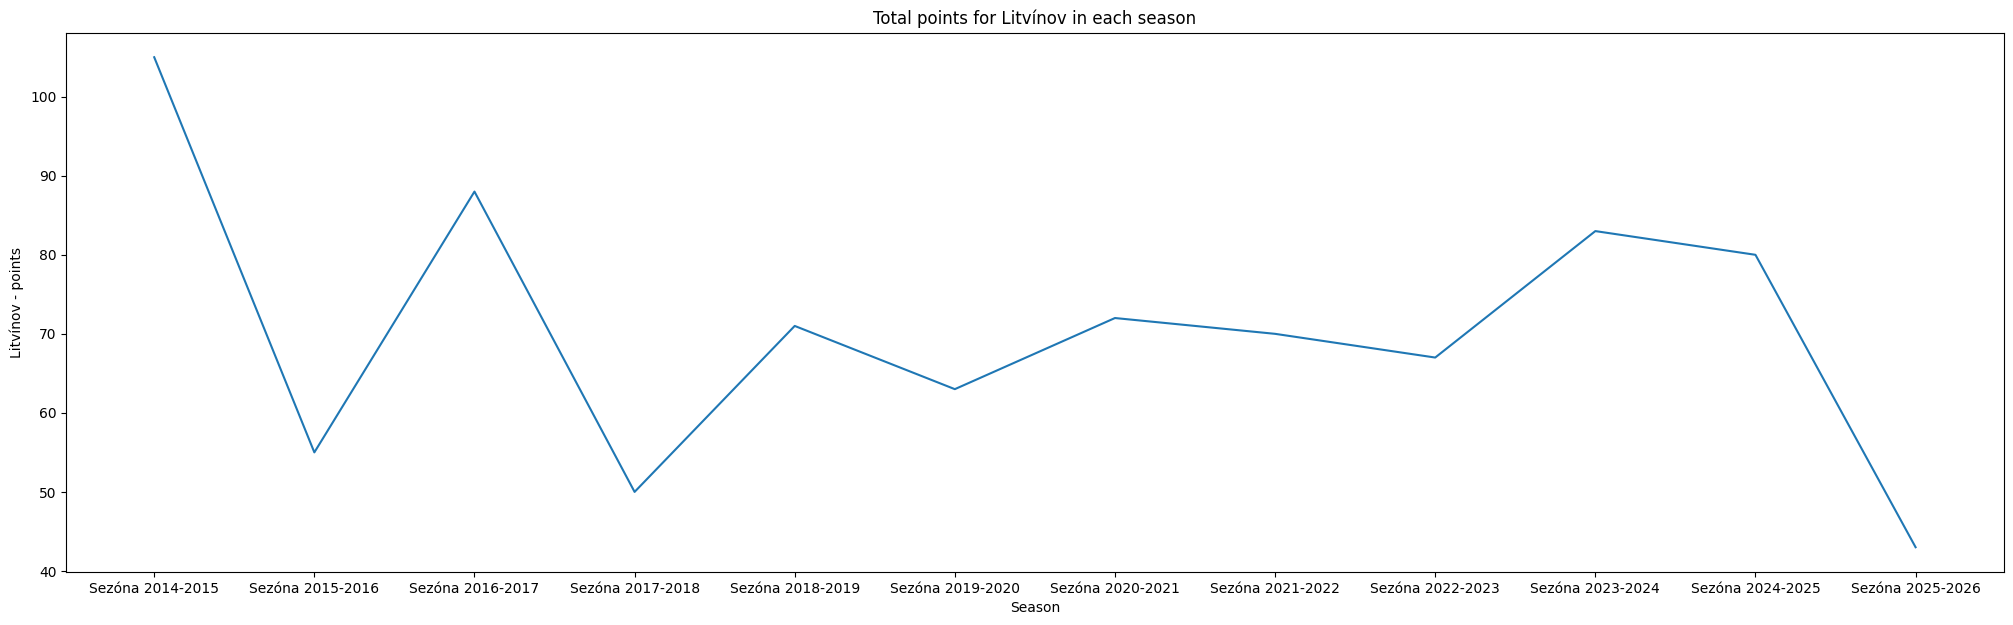

In [47]:
x = data_hockey[data_hockey["Tým"] == "HC VERVA Litvínov"]["Sezóna"]
y = data_hockey[data_hockey["Tým"] == "HC VERVA Litvínov"]["B"]

plt.figure(figsize=(25,7))
plt.plot(x, y)
plt.xlabel("Season")
plt.ylabel("Litvínov - points")
plt.title("Total points for Litvínov in each season")

['HC Oceláři Třinec' 'HC VERVA Litvínov' 'HC Kometa Brno'
 'HC Sparta Praha' 'Mountfield HK' 'RI Okna Berani Zlín' 'HC Škoda Plzeň'
 'HC VÍTKOVICE RIDERA' 'HC Dynamo Pardubice' 'BK Mladá Boleslav'
 'Bílí Tygři Liberec' 'HC Energie Karlovy Vary' 'HC Olomouc'
 'HC Slavia Praha' 'Piráti Chomutov' 'HC Dukla Jihlava' 'Rytíři Kladno'
 'Banes Motor Č. Budějovice']


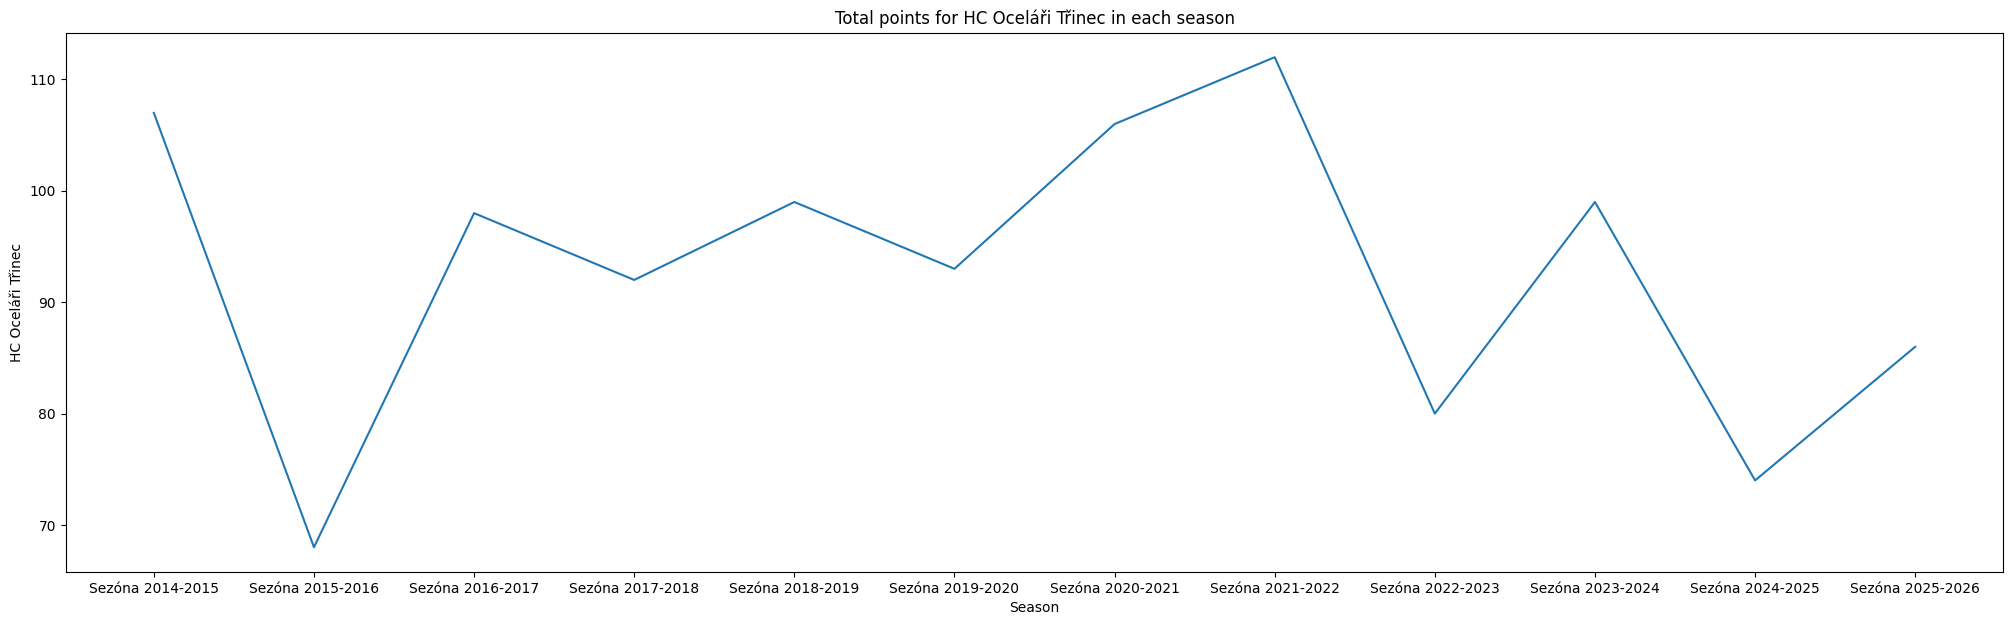

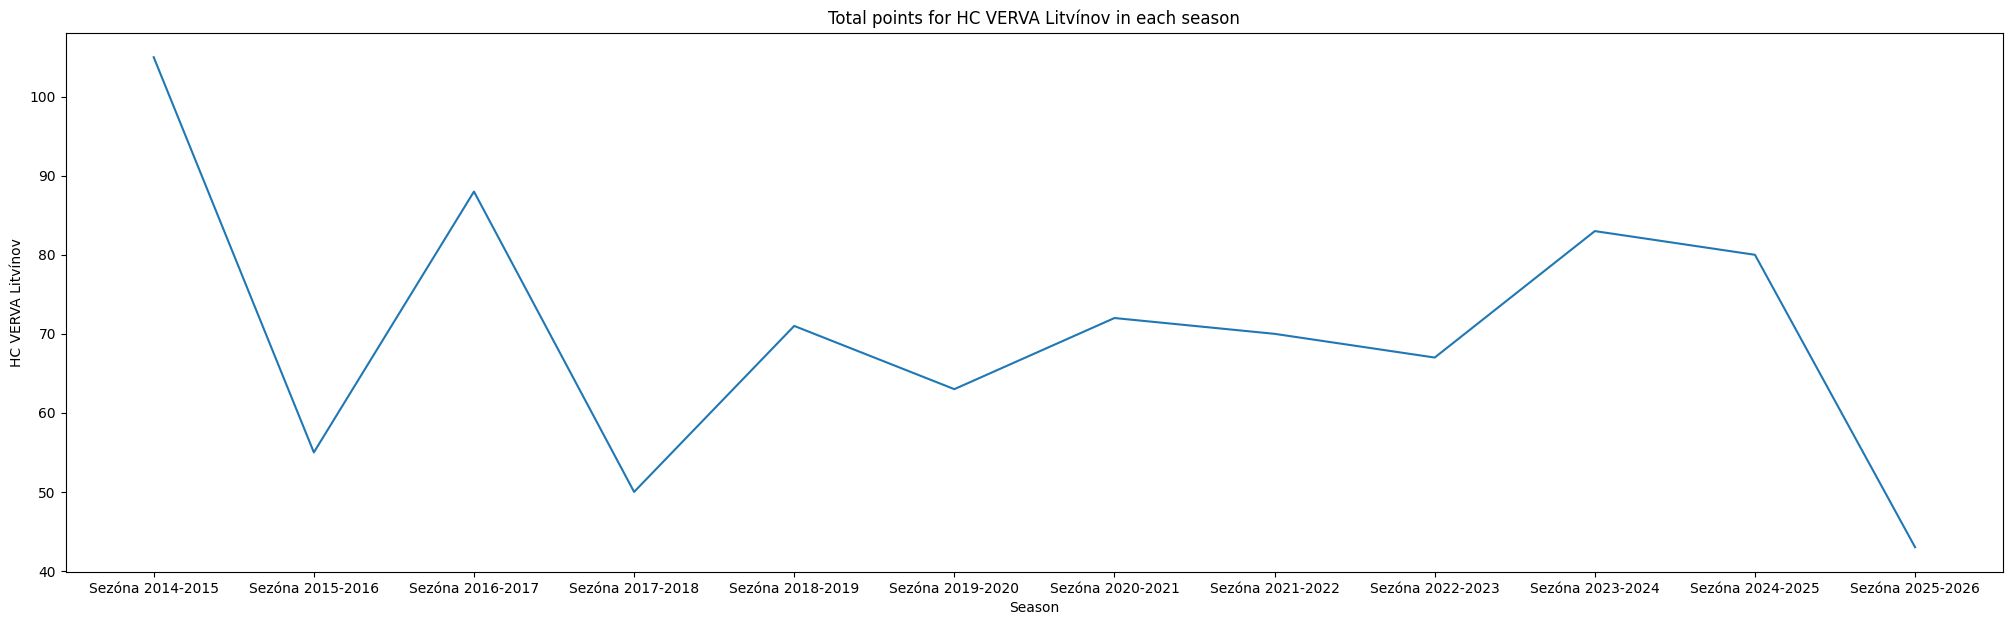

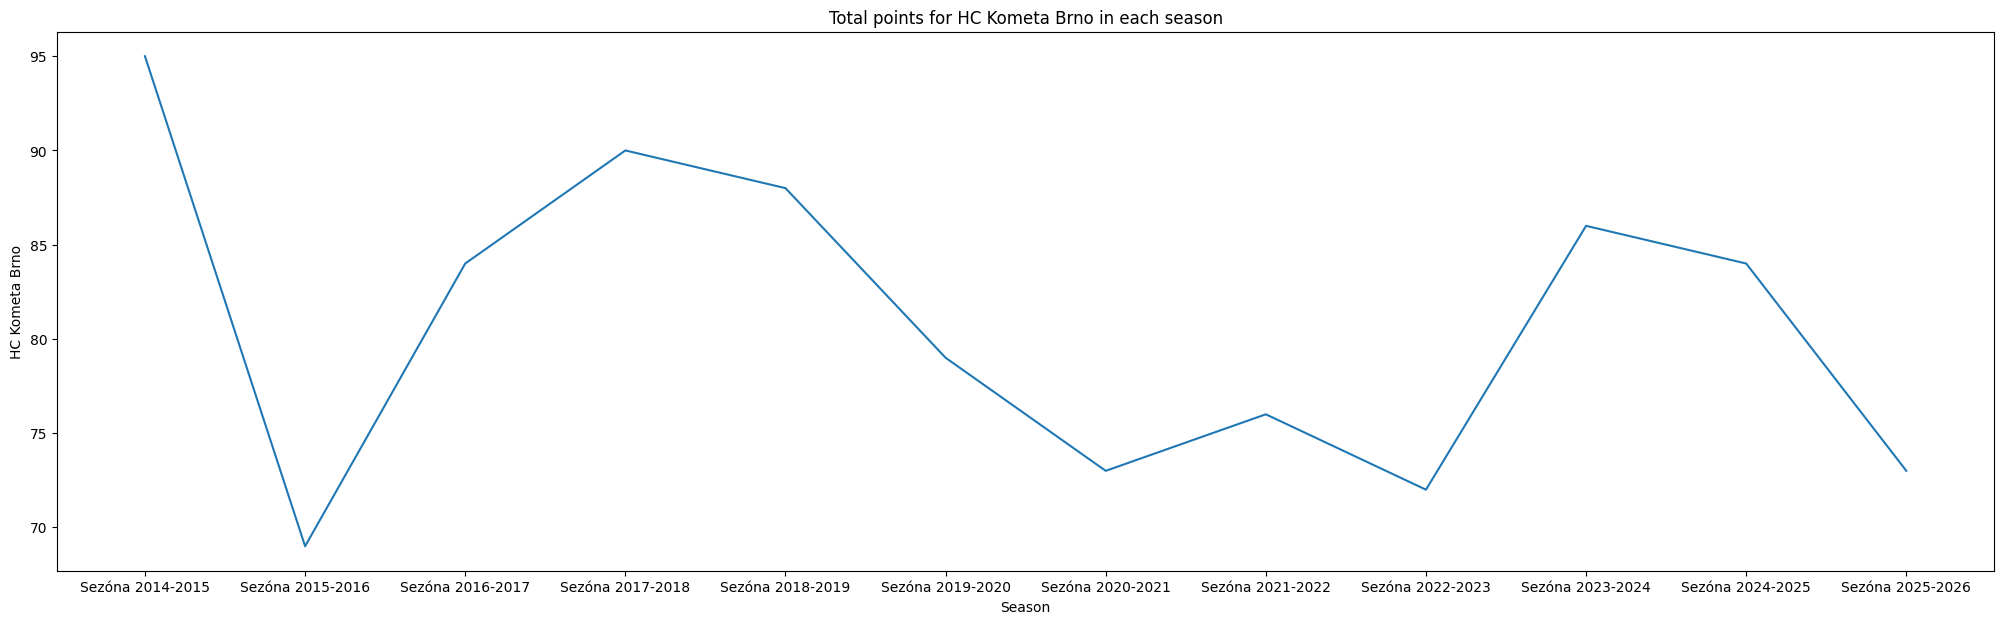

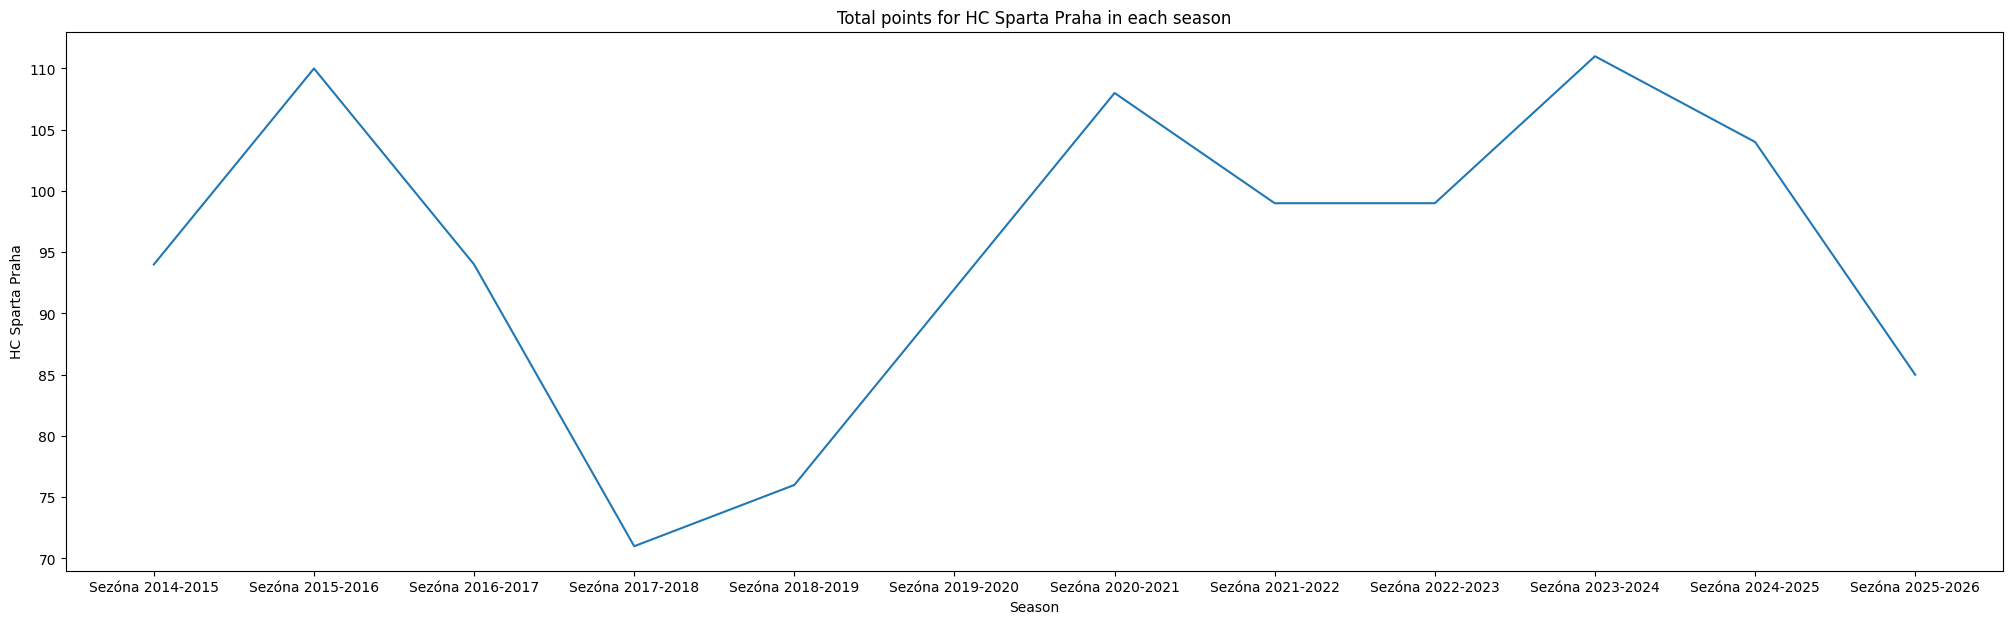

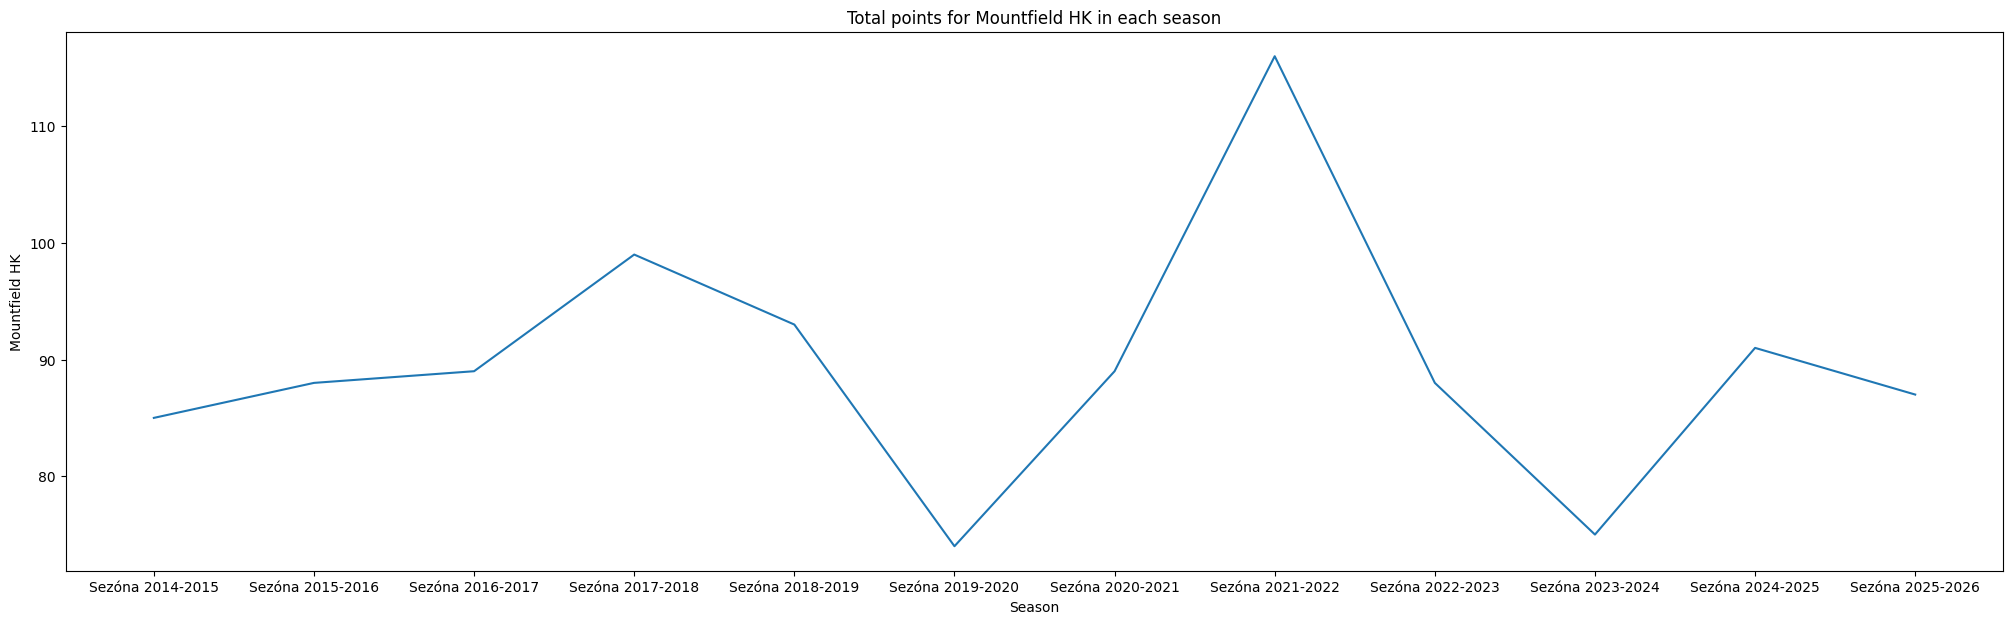

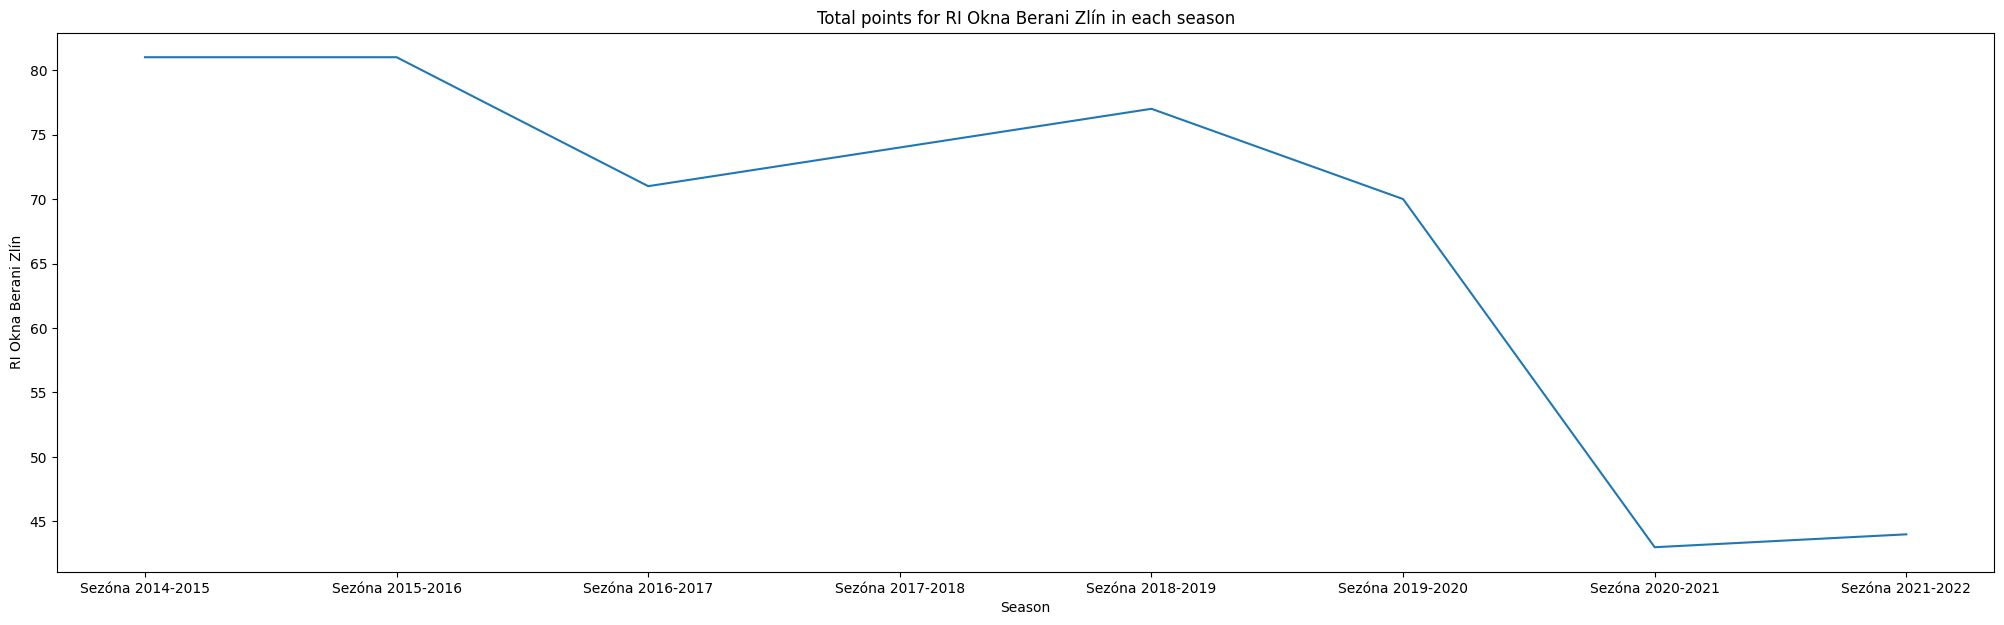

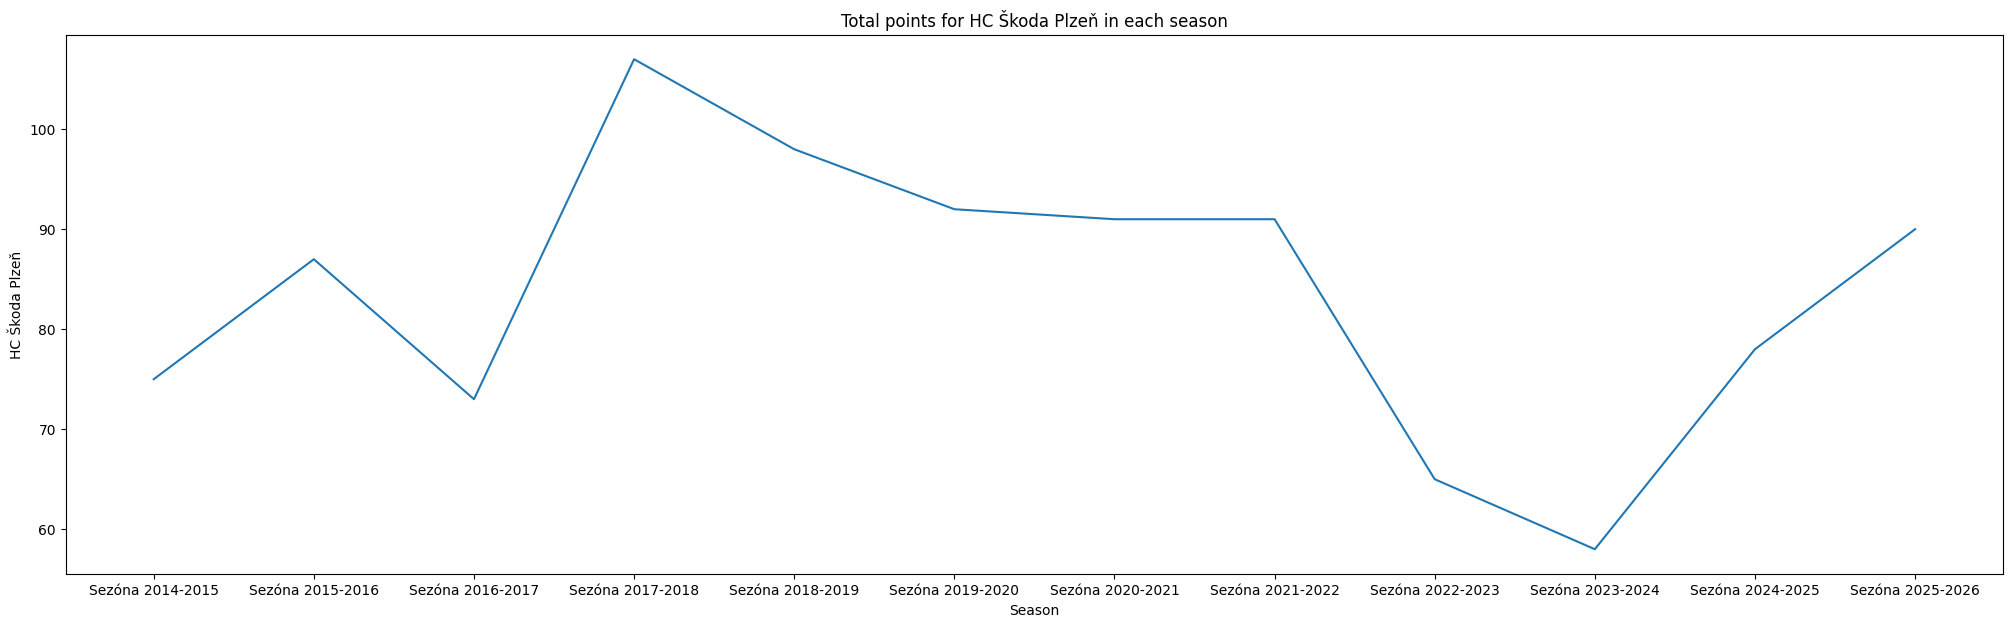

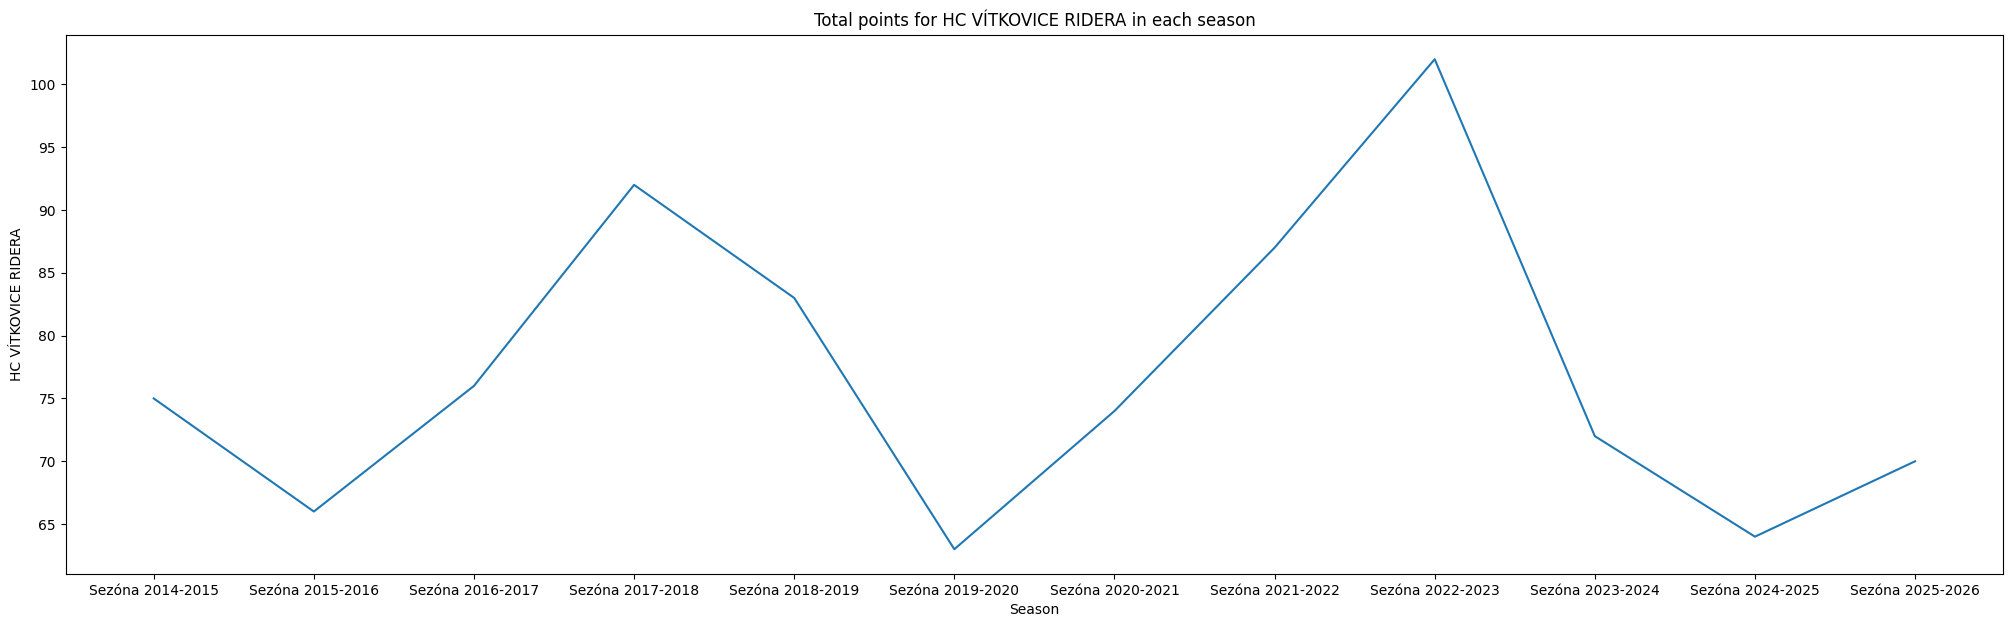

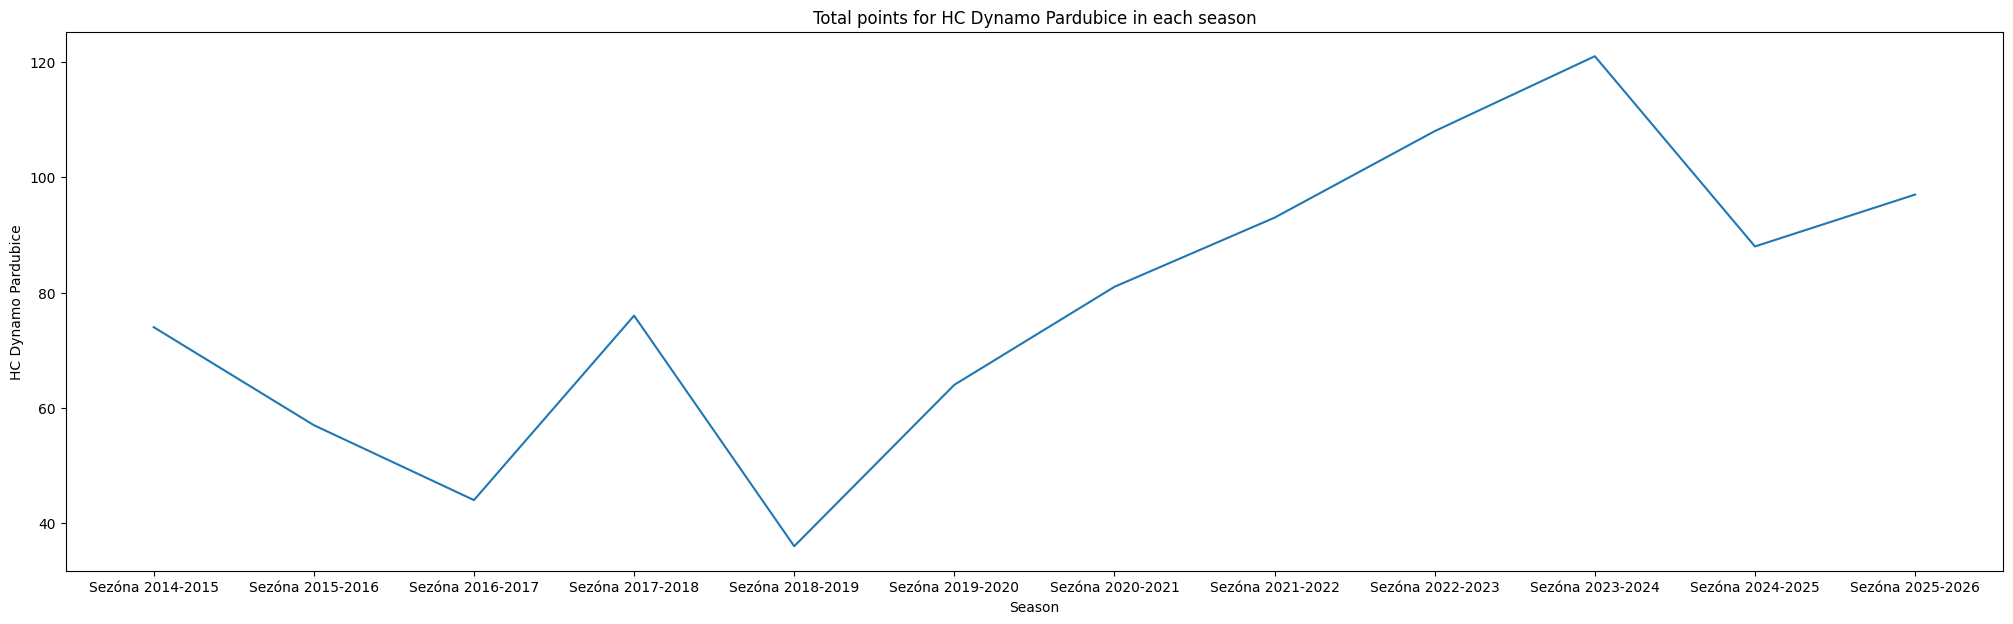

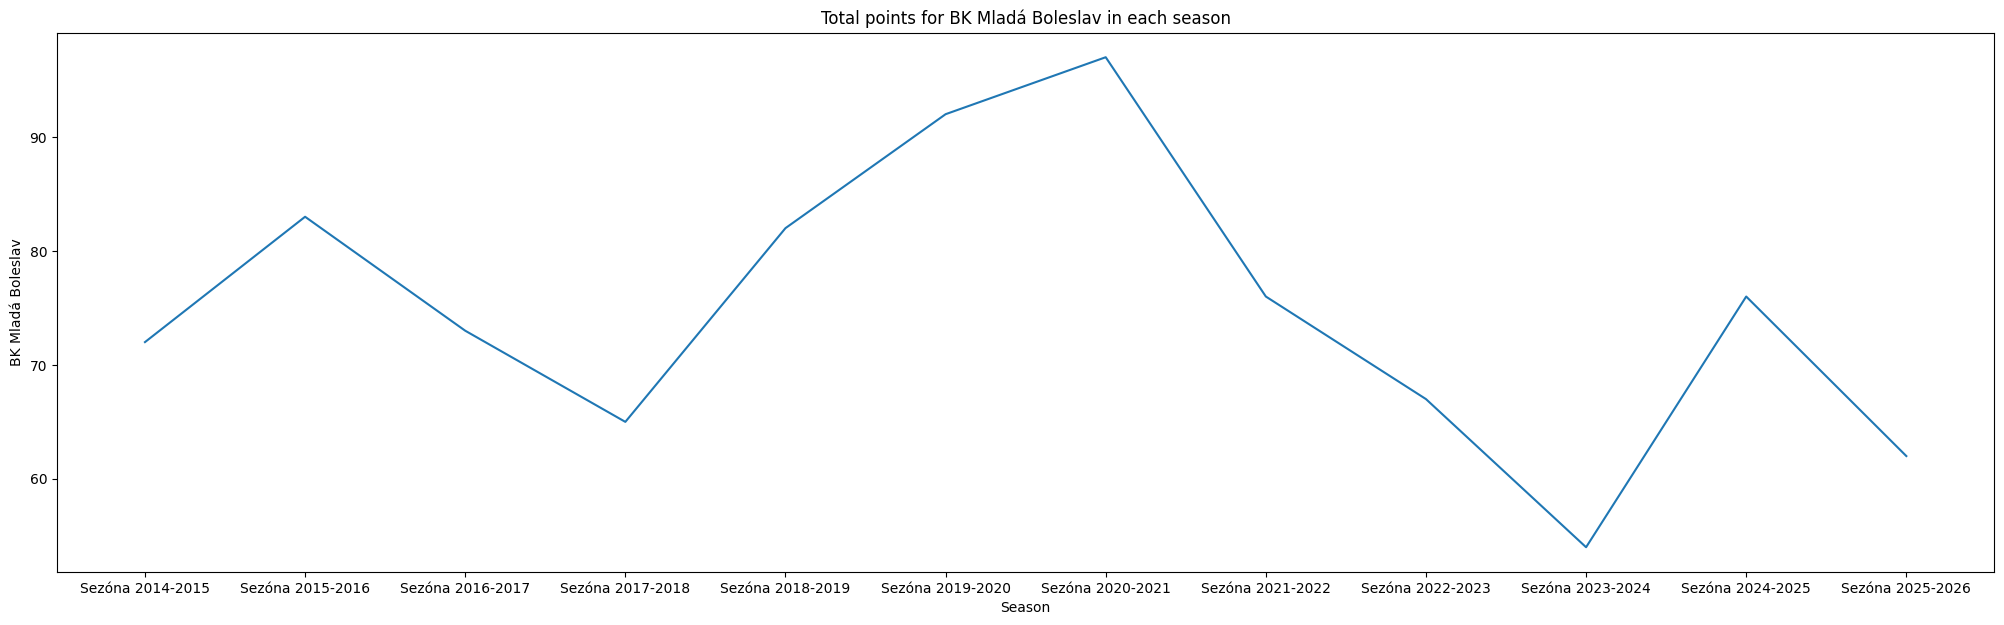

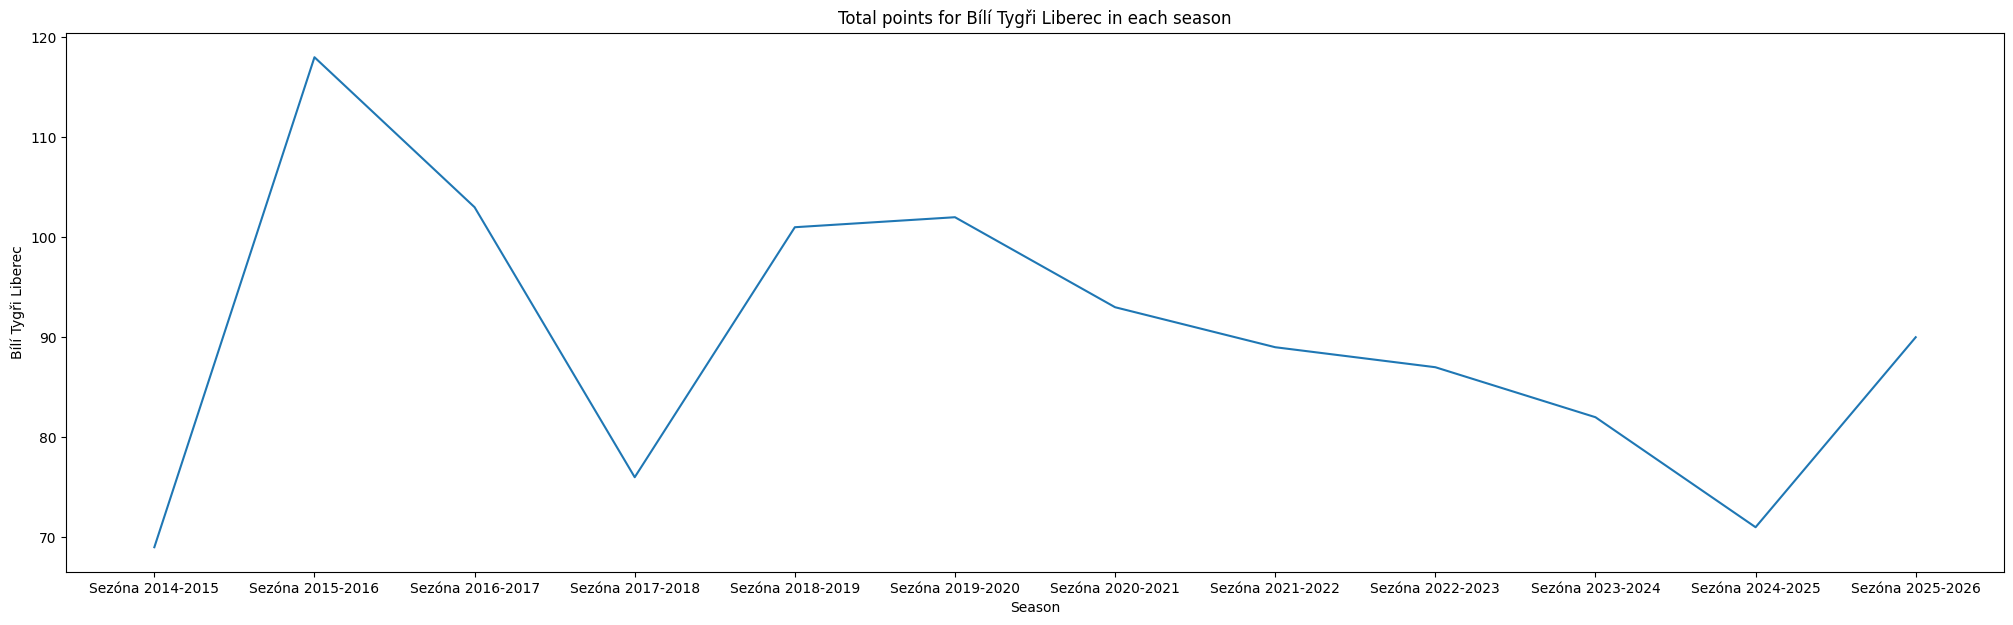

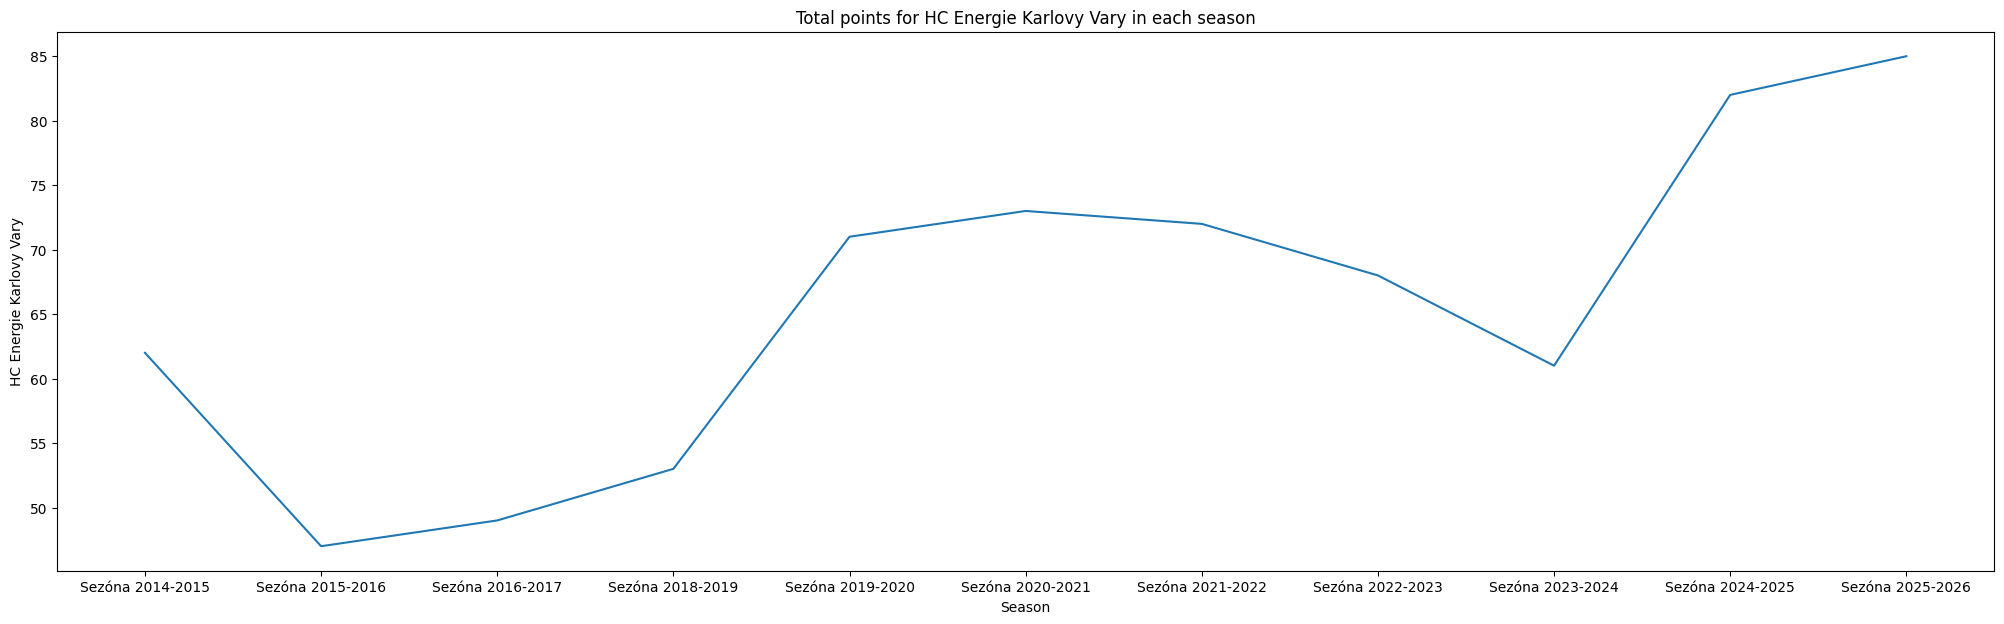

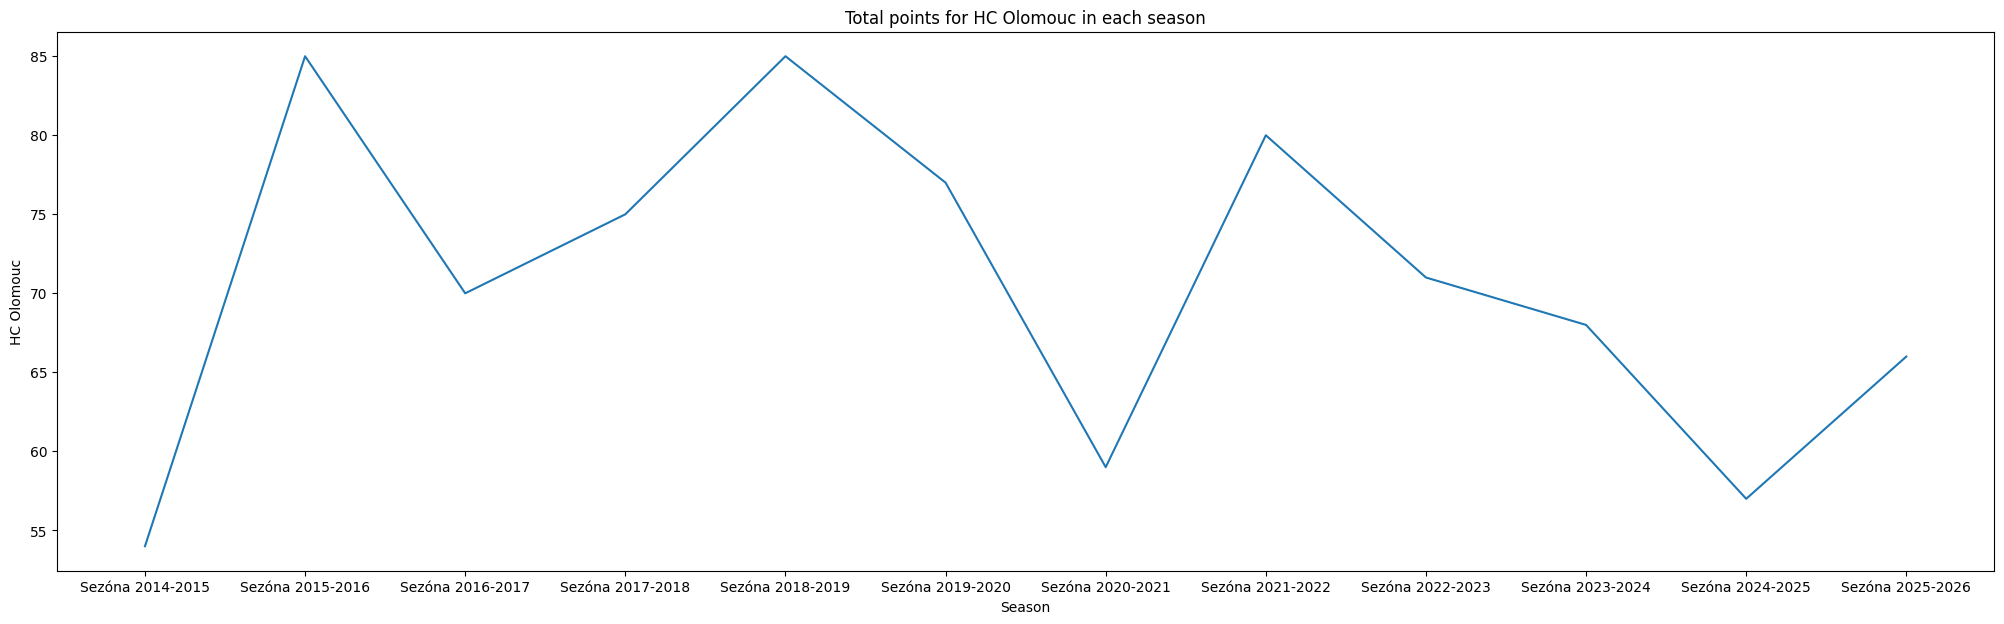

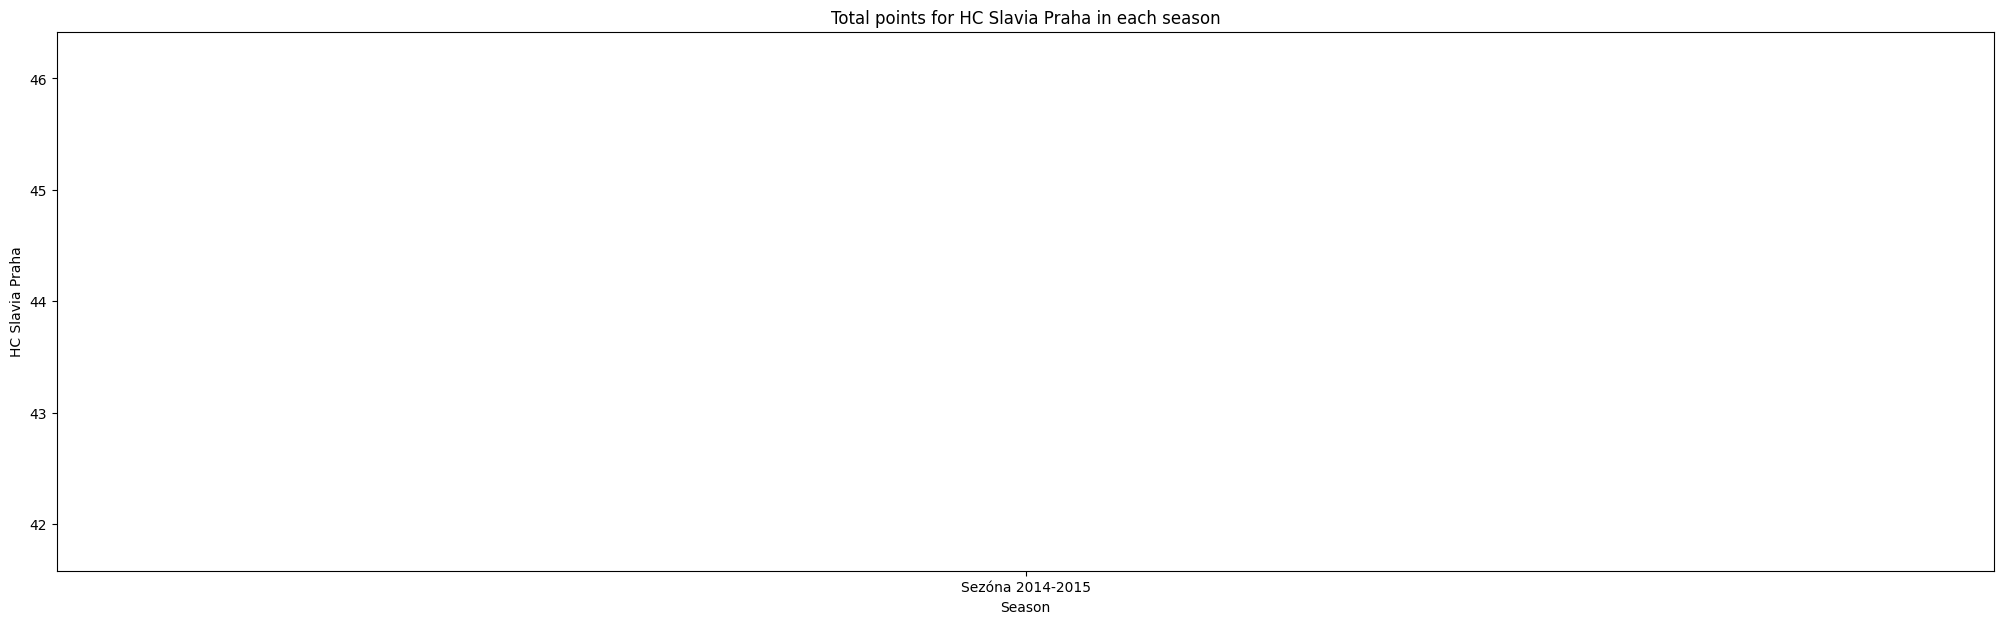

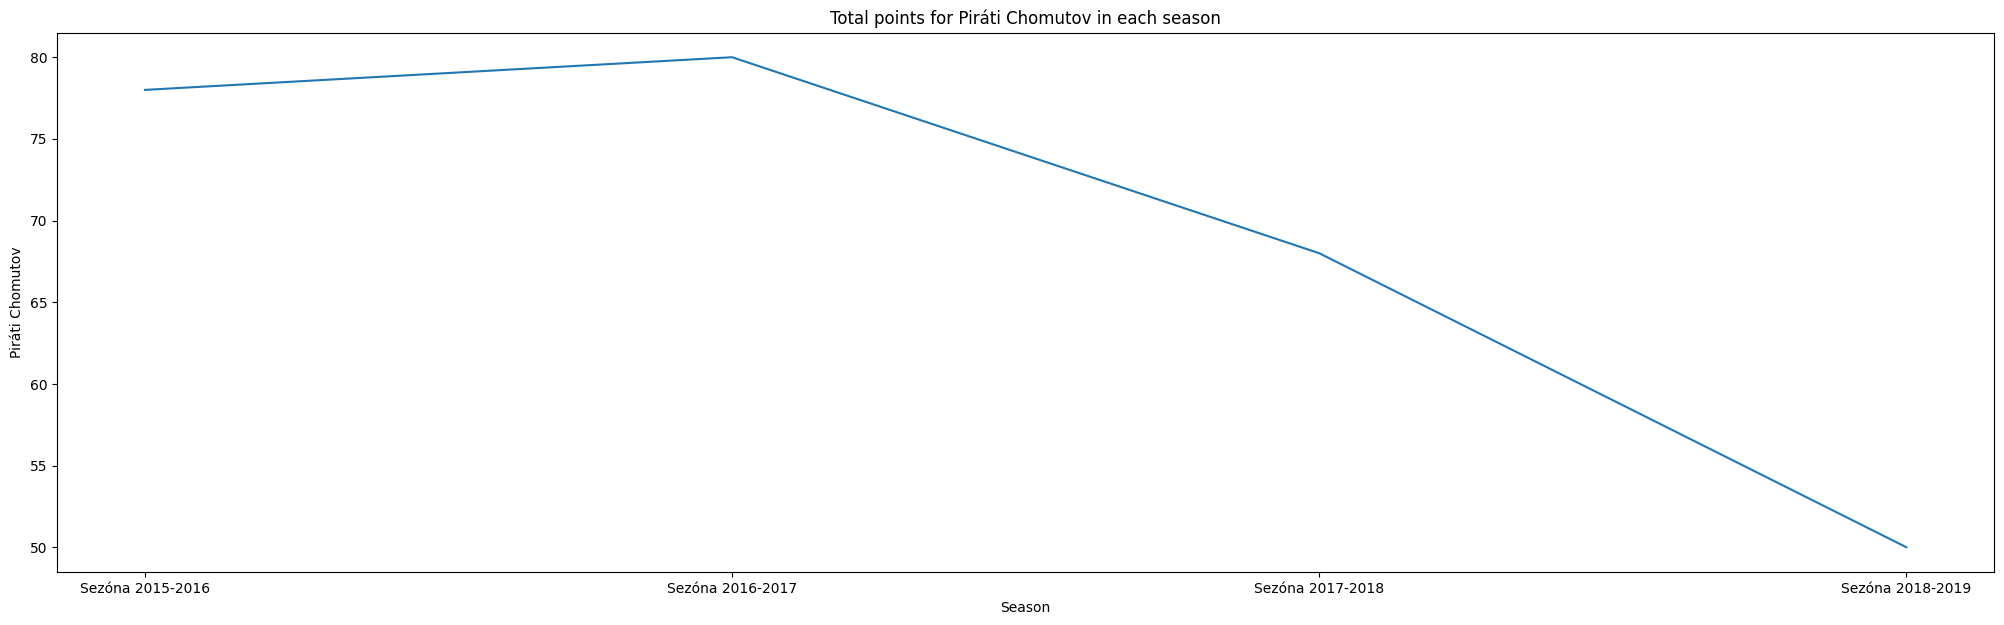

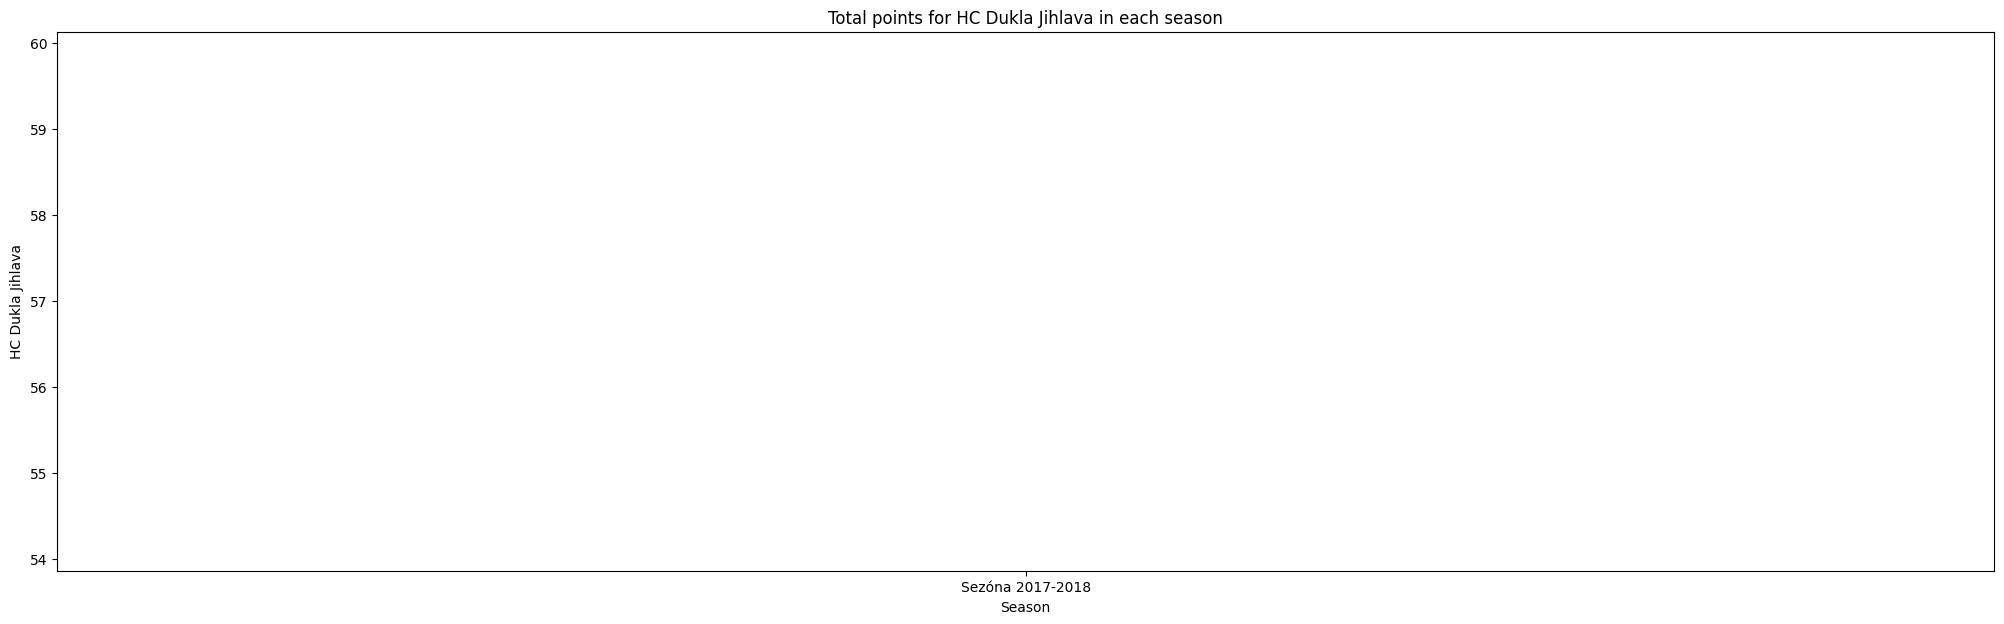

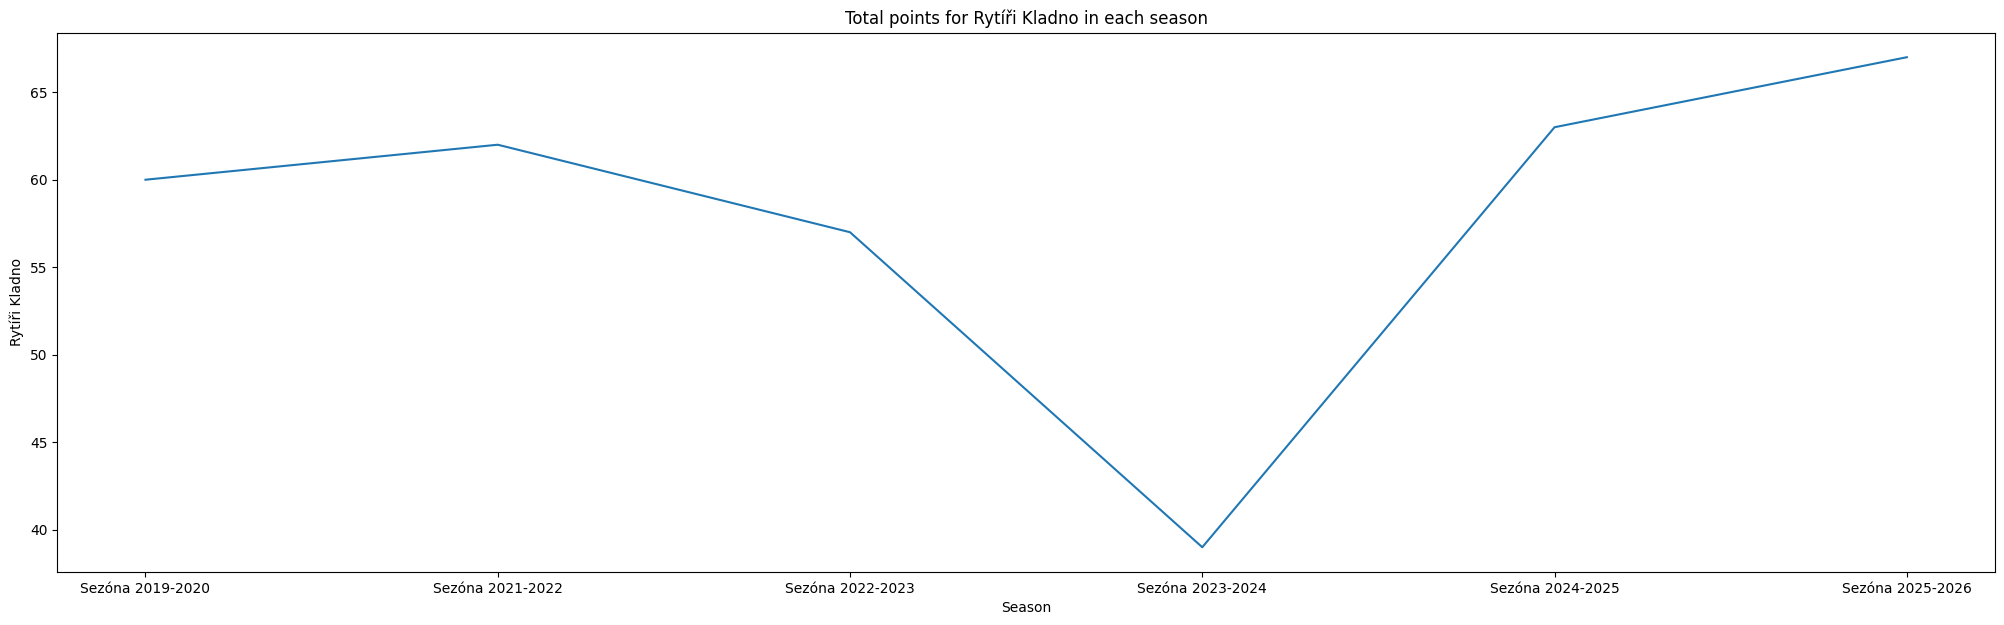

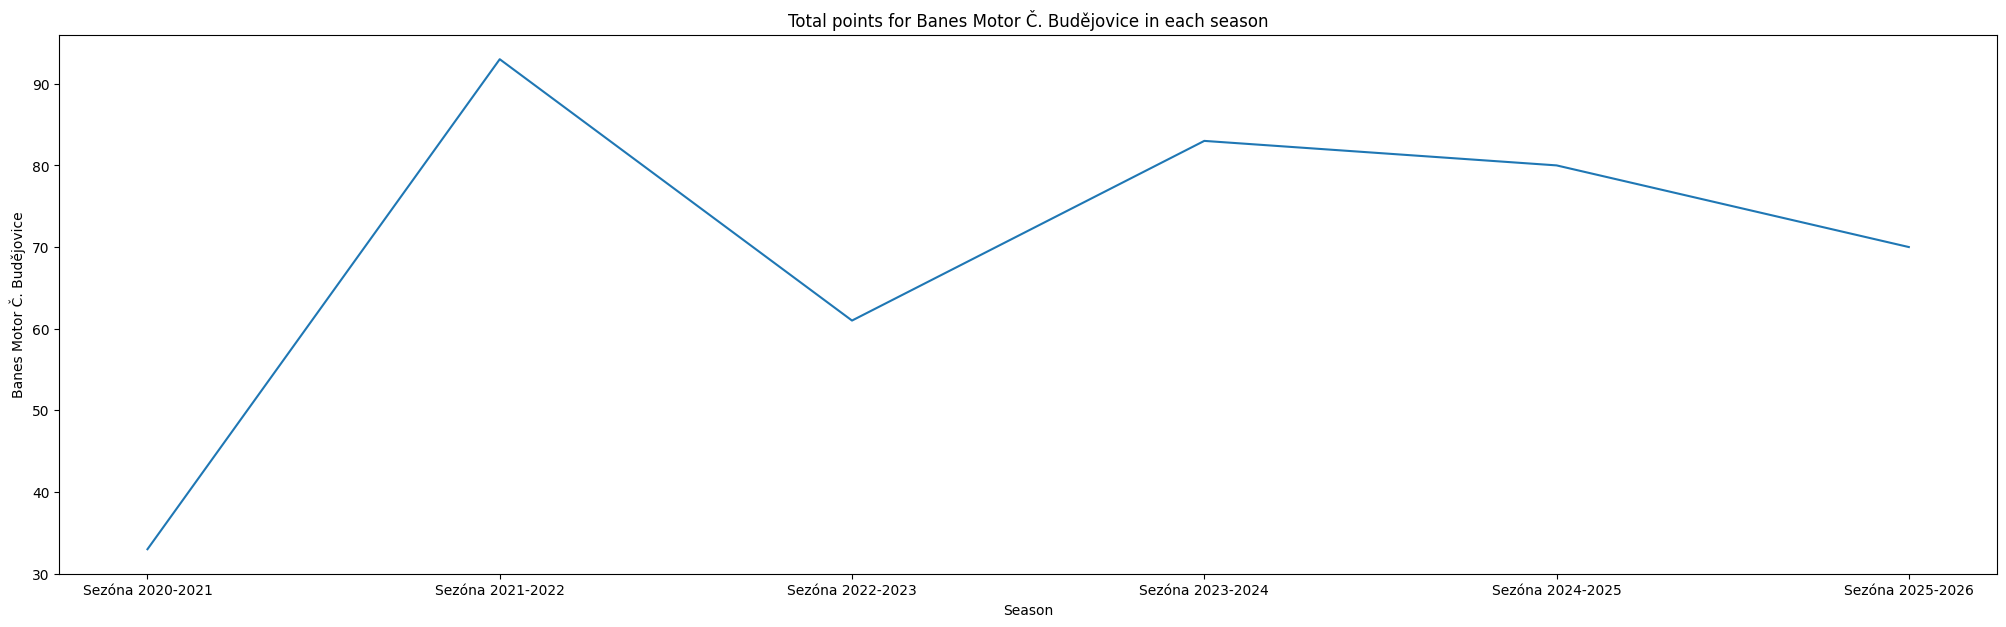

In [54]:
teams = data_hockey["Tým"].unique()
print(teams)
for team in teams:
    x = data_hockey[data_hockey["Tým"] == team]["Sezóna"]
    y = data_hockey[data_hockey["Tým"] == team]["B"]

    plt.figure(figsize=(25,7))
    plt.plot(x, y)
    plt.xlabel("Season")
    plt.ylabel(team)
    plt.title(f"Total points for {team} in each season")

In [63]:
top_teams = (
    data_hockey
    .groupby("Tým")["B"]
    .sum()
    .nlargest(5)
    .index
)
print(top_teams)
data_top5 = data_hockey[data_hockey["Tým"].isin(top_teams)]
print(data_top5)

Index(['HC Sparta Praha', 'HC Oceláři Třinec', 'Bílí Tygři Liberec',
       'Mountfield HK', 'HC Škoda Plzeň'],
      dtype='object', name='Tým')
               Sezóna   #                 Tým   Z   V  VP  PP   P    Skóre  \
0    Sezóna 2014-2015   1   HC Oceláři Třinec  52  32   4   3  13  183:117   
3    Sezóna 2014-2015   4     HC Sparta Praha  52  27   6   1  18  194:140   
4    Sezóna 2014-2015   5       Mountfield HK  52  26   3   1  22  136:131   
6    Sezóna 2014-2015   7      HC Škoda Plzeň  52  19   8   2  23  144:133   
10   Sezóna 2014-2015  11  Bílí Tygři Liberec  52  16   9   3  24  128:131   
14   Sezóna 2015-2016   1  Bílí Tygři Liberec  52  33   8   3   8  181:112   
15   Sezóna 2015-2016   2     HC Sparta Praha  52  30   7   6   9  200:132   
16   Sezóna 2015-2016   3       Mountfield HK  52  24   4   8  16  143:138   
17   Sezóna 2015-2016   4      HC Škoda Plzeň  52  23   6   6  17  165:142   
23   Sezóna 2015-2016  10   HC Oceláři Třinec  52  16   7   6  23  122:126

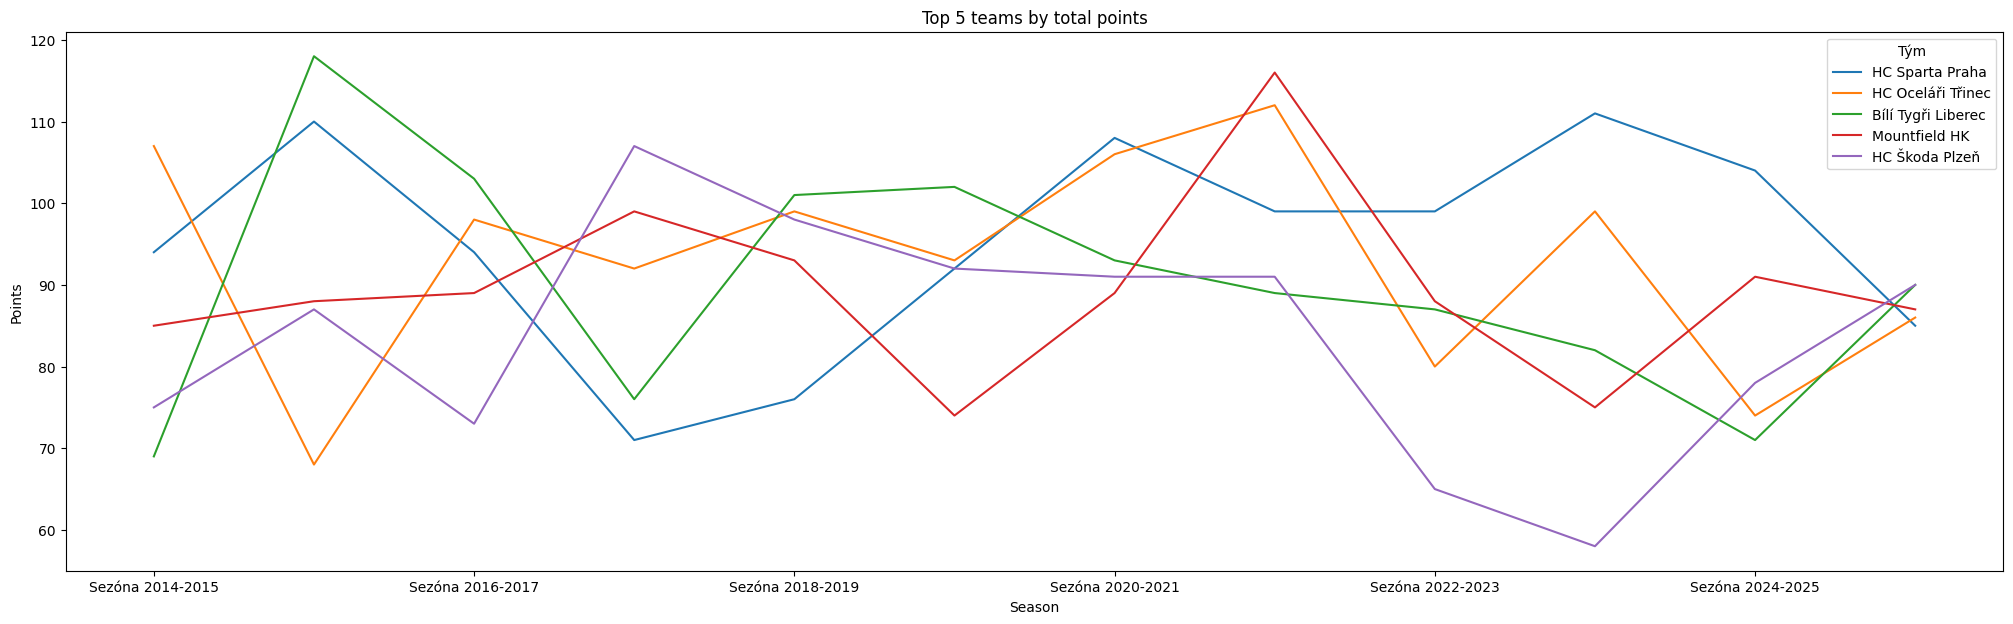

In [64]:
pivot = data_hockey.pivot(index="Sezóna", columns="Tým", values="B")

top5 = pivot.sum().nlargest(5).index

pivot[top5].plot(figsize=(25,7))

plt.xlabel("Season")
plt.ylabel("Points")
plt.title("Top 5 teams by total points")

plt.show()

In [11]:
fig = px.bar(data_hockey[data_hockey["Tým"] == "HC VERVA Litvínov"], x = "Sezóna", y= "B")

fig.show()

In [12]:
fig = px.line(data_hockey[data_hockey["Tým"] == "HC VERVA Litvínov"], x = "Sezóna", y= "B")
fig.show()

In [16]:
fig = px.scatter(data_hockey[data_hockey["Tým"] == "HC VERVA Litvínov"], x = "B", y= "V")
fig.show()

In [19]:
fig = px.bar(data_hockey, x="Sezóna", y="B", color="Tým")
fig.show()

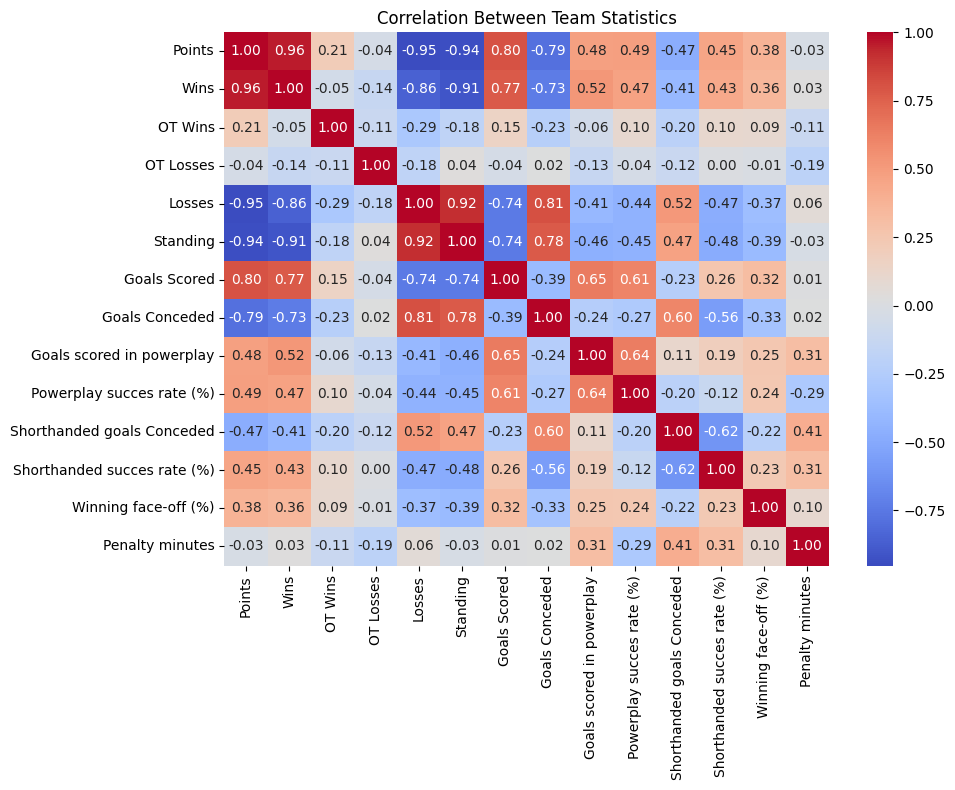

In [67]:
import seaborn as sns
import matplotlib.pyplot as plt

data_hockey = data_hockey.rename(columns={
    "B": "Points",
    "V": "Wins",
    "VP": "OT Wins",
    "PP": "OT Losses",
    "P": "Losses",
    "#": "Standing",
    "Vstř. góly": "Goals Scored",
    "Ink. góly": "Goals Conceded",
    "GPř": "Goals scored in powerplay",
    "VPř": "Powerplay succes rate (%)",
    "OGOs": "Shorthanded goals Conceded",
    "UOs": "Shorthanded succes rate (%)",
    "VV": "Winning face-off (%)",
    "T": "Penalty minutes"

})

corr = data_hockey[["Points",
    "Wins",
    "OT Wins",
    "OT Losses",
    "Losses",
    "Standing",
    "Goals Scored",
    "Goals Conceded",
    "Goals scored in powerplay",
    "Powerplay succes rate (%)",
    "Shorthanded goals Conceded",
    "Shorthanded succes rate (%)",
    "Winning face-off (%)",
    "Penalty minutes"]].corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")

plt.title("Correlation Between Team Statistics")
plt.tight_layout()
plt.show()

# Correlation matrix

### Key Insights

The correlation matrix reveals several strong relationships between team statistics.

- Points show a very strong positive correlation with wins (0.96).
- Goals scored are strongly correlated with points (0.80), indicating the importance of offensive performance.
- Goals conceded show a strong negative correlation with points (-0.79), highlighting the impact of defensive strength.
- Final league position is strongly negatively correlated with points (-0.95), which confirms that higher points totals lead to better standings.
- Powerplay efficiency contributes moderately to overall team success.
- Face-off success appears to have only a moderate impact on team performance.
- Penalty minutes show almost no correlation with team success.

Overall, both offensive and defensive performance appear to significantly influence team success.

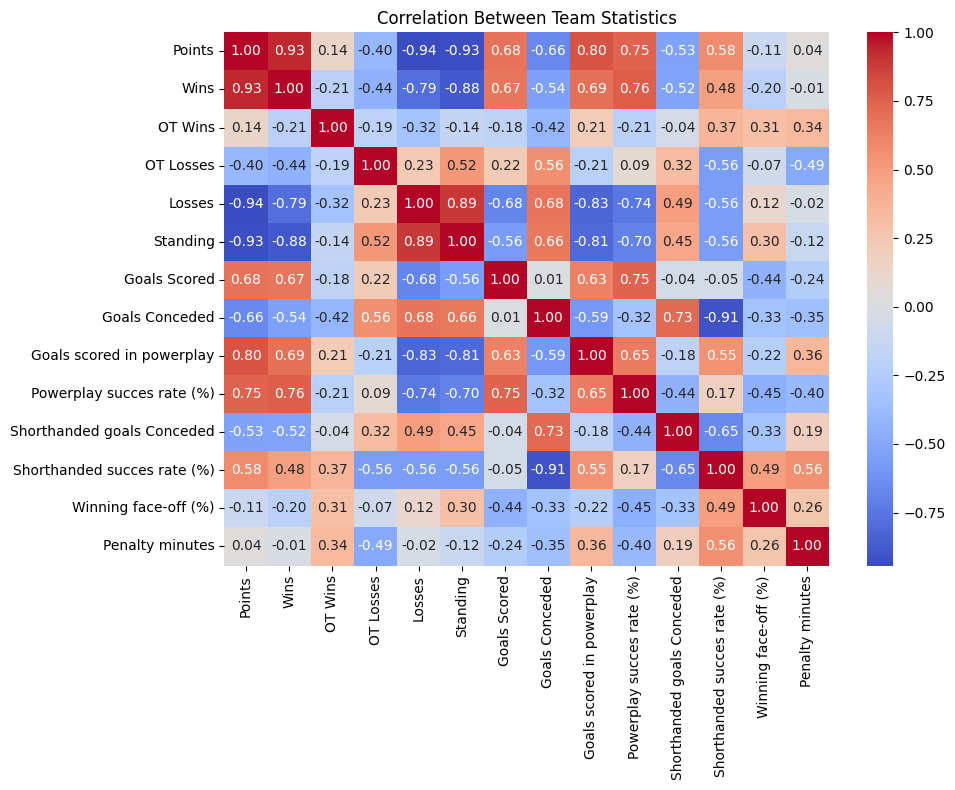

In [90]:
import seaborn as sns
import matplotlib.pyplot as plt
chosen_team = "HC VERVA Litvínov"
data_corr = data_hockey[data_hockey["Tým"] == chosen_team]
data_corr= data_corr.rename(columns={
    "B": "Points",
    "V": "Wins",
    "VP": "OT Wins",
    "PP": "OT Losses",
    "P": "Losses",
    "#": "Standing",
    "Vstř. góly": "Goals Scored",
    "Ink. góly": "Goals Conceded",
    "GPř": "Goals scored in powerplay",
    "VPř": "Powerplay succes rate (%)",
    "OGOs": "Shorthanded goals Conceded",
    "UOs": "Shorthanded succes rate (%)",
    "VV": "Winning face-off (%)",
    "T": "Penalty minutes"

})

corr = data_corr[["Points",
    "Wins",
    "OT Wins",
    "OT Losses",
    "Losses",
    "Standing",
    "Goals Scored",
    "Goals Conceded",
    "Goals scored in powerplay",
    "Powerplay succes rate (%)",
    "Shorthanded goals Conceded",
    "Shorthanded succes rate (%)",
    "Winning face-off (%)",
    "Penalty minutes"]].corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")

plt.title("Correlation Between Team Statistics")
plt.tight_layout()
plt.show()
# Correlation matrix for chosen team

### HC VERVA Litvínov – Correlation Analysis

The analysis highlights the importance of special teams performance.

- Powerplay performance shows a strong relationship with points, suggesting that effective powerplay units contribute significantly to the team's success.
- Penalty killing efficiency is strongly linked to goals conceded, indicating that strong defensive play during shorthanded situations reduces overall goals allowed.
- Penalty minutes themselves show little correlation with points, which may indicate that the team's penalty killing mitigates the impact of penalties.
- Face-off success does not appear to directly influence points, but it shows a moderate correlation with penalty killing success, face-offs may help during shorthanded.

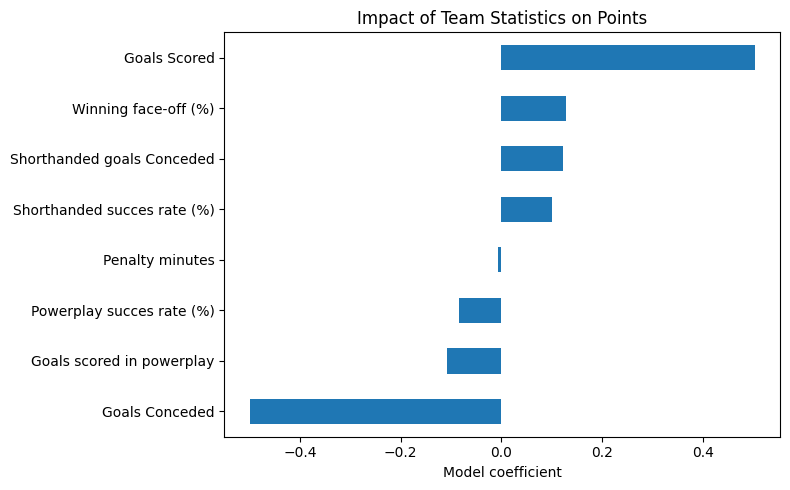

In [93]:
from sklearn.linear_model import LinearRegression
data_reg = data_hockey
data_reg= data_reg.rename(columns={
    "B": "Points",
    "Vstř. góly": "Goals Scored",
    "Ink. góly": "Goals Conceded",
    "GPř": "Goals scored in powerplay",
    "VPř": "Powerplay succes rate (%)",
    "OGOs": "Shorthanded goals Conceded",
    "UOs": "Shorthanded succes rate (%)",
    "VV": "Winning face-off (%)",
    "T": "Penalty minutes"
})
features = ["Goals Scored", "Goals Conceded", "Goals scored in powerplay", "Powerplay succes rate (%)", "Shorthanded goals Conceded", "Shorthanded succes rate (%)", "Winning face-off (%)", "Penalty minutes"]
X = data_reg[features]
y = data_reg["Points"]

model = LinearRegression()
model.fit(X, y)

importance = pd.Series(model.coef_, index=features)

importance.sort_values().plot(kind="barh", figsize=(8,5))

plt.title("Impact of Team Statistics on Points")
plt.xlabel("Model coefficient")
plt.tight_layout()
plt.show()

### Factors Influencing Team Success

The linear regression model estimates the impact of various team statistics on total points.

Key observations:

- Goals scored have the strongest positive influence on points.
- Goals conceded have the strongest negative influence, highlighting the importance of defensive performance.
- Special teams performance (powerplay and penalty killing) also contributes to team success, but to a lesser extent.
- Face-off win percentage has only a minor effect on overall performance.
- Penalty minutes appear to have almost no direct relationship with points.

Overall, the model suggests that both offensive production and defensive stability are the primary drivers of success in the Czech Extraliga.

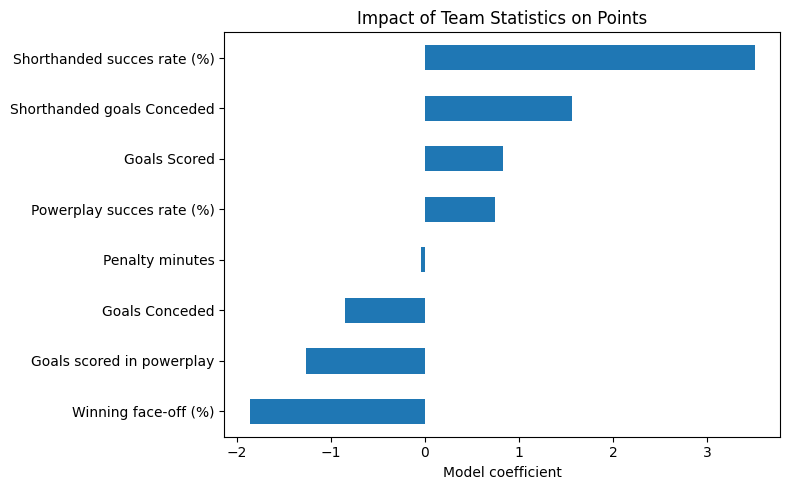

In [83]:
from sklearn.linear_model import LinearRegression
chosen_team = "HC VERVA Litvínov"
data_reg = data_hockey[data_hockey["Tým"] == chosen_team]
data_reg= data_reg.rename(columns={
    "B": "Points",
    "Vstř. góly": "Goals Scored",
    "Ink. góly": "Goals Conceded",
    "GPř": "Goals scored in powerplay",
    "VPř": "Powerplay succes rate (%)",
    "OGOs": "Shorthanded goals Conceded",
    "UOs": "Shorthanded succes rate (%)",
    "VV": "Winning face-off (%)",
    "T": "Penalty minutes"
})
features = ["Goals Scored", "Goals Conceded", "Goals scored in powerplay", "Powerplay succes rate (%)", "Shorthanded goals Conceded", "Shorthanded succes rate (%)", "Winning face-off (%)", "Penalty minutes"]
X = data_reg[features]
y = data_reg["Points"]

model = LinearRegression()
model.fit(X, y)

importance = pd.Series(model.coef_, index=features)

importance.sort_values().plot(kind="barh", figsize=(8,5))

plt.title("Impact of Team Statistics on Points")
plt.xlabel("Model coefficient")
plt.tight_layout()
plt.show()

### Regression Analysis – HC VERVA Litvínov

The regression model suggests that penalty killing efficiency has a strong influence on team success. Seasons with higher shorthanded success rates tend to be associated with higher point totals.

The model also indicates a potential relationship between face-off success and points. However, the correlation analysis shows only a weak direct relationship between face-off win percentage and points.

This may indicate that face-off performance indirectly contributes to team success through improved penalty killing performance.

Because the dataset contains a limited number of seasons, these results should be interpreted with caution.

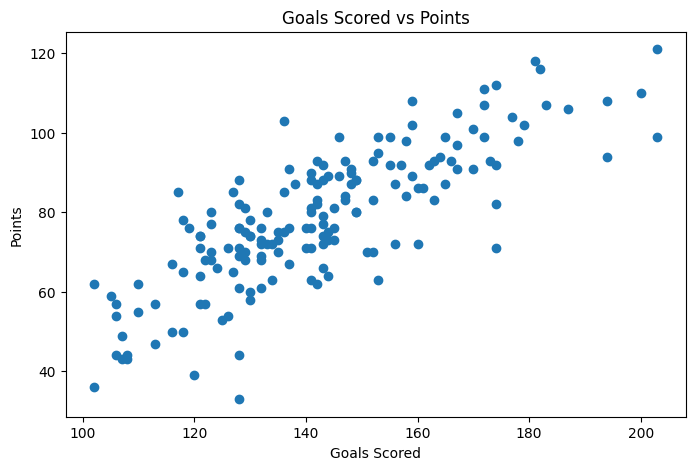

In [ ]:
plt.figure(figsize=(8,5))
plt.scatter(data_hockey["Vstř. góly"], data_hockey["B"])

plt.xlabel("Goals Scored")
plt.ylabel("Points")
plt.title("Goals Scored vs Points")

plt.show()
# Picture shows strong impact of number of scored goals on total points.

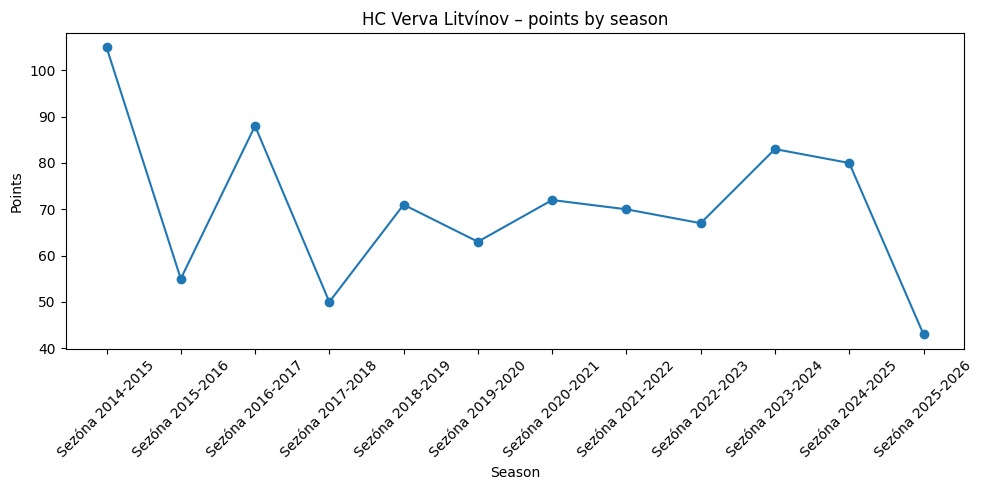

In [13]:
litvinov_points = data_hockey[data_hockey["Tým"] == "HC VERVA Litvínov"]

plt.figure(figsize=(10,5))
plt.plot(litvinov_points["Sezóna"], litvinov_points["B"], marker="o")
plt.xticks(rotation=45)
plt.title("HC Verva Litvínov – points by season")
plt.xlabel("Season")
plt.ylabel("Points")
plt.tight_layout()
plt.show()

## Players statistics

In [5]:
data_players_stats = pd.read_excel("Hockey-stats and tables.xlsx", sheet_name="Statistiky extraliga ZČ", index_col="POŘ.")
print(data_players_stats)

                   JMÉNO                        TÝM POZ.  GP      TOI   G   A  \
POŘ.                                                                            
1            Viktor Hübl          HC VERVA Litvínov    Ú  51  1057:30  21  37   
2        Martin Ručinský          HC VERVA Litvínov    Ú  51  1049:00  19  35   
3            Tomáš Mertl              Mountfield HK    Ú  50  1030:33  24  26   
4        Jaroslav Hlinka            HC Sparta Praha    Ú  48   952:24  17  33   
5              Erik Hrňa          HC Oceláři Třinec    Ú  45   751:27  26  21   
...                  ...                        ...  ...  ..      ...  ..  ..   
429   František Formánek        HC Dynamo Pardubice    Ú  14    81:13   0   0   
430       Matyáš Humeník  Banes Motor Č. Budějovice    Ú  15    55:31   0   0   
431         Robin Kaplan        HC Dynamo Pardubice    Ú  19   119:16   0   0   
432         David Škůrek                 HC Olomouc    O  22   197:41   0   0   
433         Tomáš Havlín    

In [6]:
print(
    data_players_stats.loc[
        (data_players_stats["TÝM"] == "HC VERVA Litvínov") &
        (data_players_stats["Sezóna"] == "Sezóna 2025-2026") &
        (data_players_stats["POZ."] == "Ú")
    ]
)


                   JMÉNO                TÝM POZ.  GP     TOI   G   A   P    S  \
POŘ.                                                                            
58           Ondřej Kaše  HC VERVA Litvínov    Ú  33  701:04   8  17  25  104   
80           Matúš Sukeľ  HC VERVA Litvínov    Ú  44  912:31  10  11  21   61   
104   Markus Hännikäinen  HC VERVA Litvínov    Ú  43  773:12   7  11  18   65   
112        Nicolas Hlava  HC VERVA Litvínov    Ú  50  837:57  10   7  17  122   
113    Matěj Maštalířský  HC VERVA Litvínov    Ú  46  668:37   9   8  17   63   
116         Petr Koblasa  HC VERVA Litvínov    Ú  51  785:17   7  10  17   81   
127           David Kaše  HC VERVA Litvínov    Ú  28  532:21   6  10  16   71   
133       Theodor Pištěk  HC VERVA Litvínov    Ú  52  805:07  12   3  15   94   
161       Axel Holmström  HC VERVA Litvínov    Ú  26  348:18   6   6  12   18   
165       Maxim Čajkovič  HC VERVA Litvínov    Ú  37  450:07   4   8  12   56   
183        Jaroslav Brož  HC

In [7]:
print(
    data_players_stats.loc[
        (data_players_stats["Sezóna"] == "Sezóna 2025-2026") &
        (data_players_stats["POZ."] == "O")
    ][["JMÉNO", "TÝM", "GP", "G", "A", "P"]].head(50)
)


                     JMÉNO                        TÝM  GP   G   A   P
POŘ.                                                                 
9             Jan Košťálek        HC Dynamo Pardubice  46  16  27  43
22         Libor Zábranský             HC Kometa Brno  52  18  15  33
41           Petr Zámorský             HC Škoda Plzeň  49  11  17  28
46         Miguël Tourigny        HC Dynamo Pardubice  50   8  19  27
47             Jan Štencel  Banes Motor Č. Budějovice  51   8  19  27
53           Jakub Krejčík            HC Sparta Praha  44   3  23  26
56              Janis Jaks    HC Energie Karlovy Vary  48  10  15  25
63           T.J. Melancon              Mountfield HK  51  11  13  24
65            Tomáš Galvas         Bílí Tygři Liberec  32   8  16  24
77           Tomáš Cibulka  Banes Motor Č. Budějovice  47   7  15  22
78           Ville Lajunen             HC Škoda Plzeň  45   6  16  22
84              Mark Pysyk            HC Sparta Praha  50   6  15  21
90           Marian 

In [8]:
tab_LIT = data_hockey.loc[
        (data_hockey["Tým"] == "HC VERVA Litvínov")
    ][["Sezóna", "Z", "V", "VP", "PP", "P", "B", "Skóre"]]


print(tab_LIT)

               Sezóna   Z   V  VP  PP   P    B    Skóre
1    Sezóna 2014-2015  52  30   6   3  13  105  167:120
26   Sezóna 2015-2016  52  10  10   5  27   55  110:138
32   Sezóna 2016-2017  52  20  13   2  17   88  128:126
55   Sezóna 2017-2018  52  10   7   6  29   50  118:168
66   Sezóna 2018-2019  52  20   5   1  26   71  128:147
81   Sezóna 2019-2020  52  16   3   9  24   63  153:173
94   Sezóna 2020-2021  52  17   8   5  22   72  133:146
110  Sezóna 2021-2022  56  18   4   8  26   70  152:173
123  Sezóna 2022-2023  52  15   7   8  22   67  137:144
131  Sezóna 2023-2024  52  23   5   4  20   83  163:165
147  Sezóna 2024-2025  52  25   1   3  23   80  123:128
168  Sezóna 2025-2026  52  11   3   4  34   43  107:174


In [41]:
print(
    data_players_stats.loc[
        (data_players_stats["TÝM"] == "HC VERVA Litvínov")
    ]
)


                 JMÉNO                TÝM POZ.  GP      TOI   G   A   P    S  \
POŘ.                                                                           
1          Viktor Hübl  HC VERVA Litvínov    Ú  51  1057:30  21  37  58  177   
2      Martin Ručinský  HC VERVA Litvínov    Ú  51  1049:00  19  35  54  155   
14     František Lukeš  HC VERVA Litvínov    Ú  43   836:31  18  22  40  128   
36        Peter Jánský  HC VERVA Litvínov    Ú  42   693:02  16  15  31   83   
58    Jakub Petružálek  HC VERVA Litvínov    Ú  28   465:39  12  14  26   86   
...                ...                ...  ...  ..      ...  ..  ..  ..  ...   
382          Vít Beran  HC VERVA Litvínov    O   2    21:54   0   0   0    2   
385    Přemysl Svoboda  HC VERVA Litvínov    Ú   2    15:41   0   0   0    0   
399        Marek Berka  HC VERVA Litvínov    Ú   3    22:35   0   0   0    1   
400     Marek Peroutka  HC VERVA Litvínov    Ú   3    30:47   0   0   0    3   
415     Jonáš Bednařík  HC VERVA Litvíno

In [42]:
seasons = data_players_stats["Sezóna"].unique()

for season in seasons:
    print(season)

Sezóna 2014-2015
Sezóna 2015-2016
Sezóna 2016-2017
Sezóna 2017-2018
Sezóna 2018-2019
Sezóna 2019-2020
Sezóna 2020-2021
Sezóna 2021-2022
Sezóna 2022-2023
Sezóna 2023-2024
Sezóna 2024-2025
Sezóna 2025-2026


In [43]:
seasons = data_players_stats["Sezóna"].unique()

print(
    data_players_stats.loc[
        (data_players_stats["TÝM"] == "HC VERVA Litvínov")][["Sezóna", "P"]]
)

print(
    data_players_stats.loc[
        (data_players_stats["TÝM"] == "HC VERVA Litvínov") & (data_players_stats["P"] == 58)][["JMÉNO", "Sezóna", "P"]]
)



                Sezóna   P
POŘ.                      
1     Sezóna 2014-2015  58
2     Sezóna 2014-2015  54
14    Sezóna 2014-2015  40
36    Sezóna 2014-2015  31
58    Sezóna 2014-2015  26
...                ...  ..
382   Sezóna 2025-2026   0
385   Sezóna 2025-2026   0
399   Sezóna 2025-2026   0
400   Sezóna 2025-2026   0
415   Sezóna 2025-2026   0

[386 rows x 2 columns]
            JMÉNO            Sezóna   P
POŘ.                                   
1     Viktor Hübl  Sezóna 2014-2015  58


In [44]:
for season in seasons:
    season_data = data_players_stats[
        (data_players_stats["TÝM"] == "HC VERVA Litvínov") &
        (data_players_stats["Sezóna"] == season)
    ]

    max_points = season_data["P"].max()
    top_players = season_data[season_data["P"] == max_points]

    print(season)
    print(top_players[["JMÉNO", "P"]])
    print()

Sezóna 2014-2015
            JMÉNO   P
POŘ.                 
1     Viktor Hübl  58

Sezóna 2015-2016
            JMÉNO   P
POŘ.                 
29    Viktor Hübl  32
31    Robin Hanzl  32

Sezóna 2016-2017
                JMÉNO   P
POŘ.                     
8     František Lukeš  40

Sezóna 2017-2018
            JMÉNO   P
POŘ.                 
9     Viktor Hübl  39

Sezóna 2018-2019
                JMÉNO   P
POŘ.                     
14    František Lukeš  34

Sezóna 2019-2020
                JMÉNO   P
POŘ.                     
15    Richard Jarůšek  38

Sezóna 2020-2021
            JMÉNO   P
POŘ.                 
16    Viktor Hübl  37

Sezóna 2021-2022
                 JMÉNO   P
POŘ.                      
9     Giorgio Estephan  48

Sezóna 2022-2023
               JMÉNO   P
POŘ.                    
11    Šimon Stránský  40

Sezóna 2023-2024
            JMÉNO   P
POŘ.                 
3     Ondřej Kaše  54

Sezóna 2024-2025
            JMÉNO   P
POŘ.                 
10    Ondřej Kaše

In [45]:
litvinov_players = data_players_stats[
    data_players_stats["TÝM"] == "HC VERVA Litvínov"
].copy()

litvinov_players["P"] = pd.to_numeric(litvinov_players["P"], errors="coerce")

litvinov_players = litvinov_players.reset_index(drop=True)

top_players = litvinov_players.loc[
    litvinov_players.groupby("Sezóna")["P"].idxmax(),
    ["Sezóna", "JMÉNO", "P"]
].rename(columns={
    "JMÉNO": "Nejproduktivnejsi_hrac",
    "P": "Body_top_hrace"
})

print(top_players)

               Sezóna Nejproduktivnejsi_hrac  Body_top_hrace
0    Sezóna 2014-2015            Viktor Hübl              58
29   Sezóna 2015-2016            Viktor Hübl              32
60   Sezóna 2016-2017        František Lukeš              40
96   Sezóna 2017-2018            Viktor Hübl              39
136  Sezóna 2018-2019        František Lukeš              34
170  Sezóna 2019-2020        Richard Jarůšek              38
202  Sezóna 2020-2021            Viktor Hübl              37
232  Sezóna 2021-2022       Giorgio Estephan              48
263  Sezóna 2022-2023         Šimon Stránský              40
291  Sezóna 2023-2024            Ondřej Kaše              54
318  Sezóna 2024-2025            Ondřej Kaše              41
354  Sezóna 2025-2026            Ondřej Kaše              25


In [46]:
team_stats_with_top = tab_LIT.merge(
    top_players,
    on="Sezóna",
    how="left"
).set_index("Sezóna")

print(team_stats_with_top)

                   Z   V  VP  PP   P    B    Skóre Nejproduktivnejsi_hrac  \
Sezóna                                                                      
Sezóna 2014-2015  52  30   6   3  13  105  167:120            Viktor Hübl   
Sezóna 2015-2016  52  10  10   5  27   55  110:138            Viktor Hübl   
Sezóna 2016-2017  52  20  13   2  17   88  128:126        František Lukeš   
Sezóna 2017-2018  52  10   7   6  29   50  118:168            Viktor Hübl   
Sezóna 2018-2019  52  20   5   1  26   71  128:147        František Lukeš   
Sezóna 2019-2020  52  16   3   9  24   63  153:173        Richard Jarůšek   
Sezóna 2020-2021  52  17   8   5  22   72  133:146            Viktor Hübl   
Sezóna 2021-2022  56  18   4   8  26   70  152:173       Giorgio Estephan   
Sezóna 2022-2023  52  15   7   8  22   67  137:144         Šimon Stránský   
Sezóna 2023-2024  52  23   5   4  20   83  163:165            Ondřej Kaše   
Sezóna 2024-2025  52  25   1   3  23   80  123:128            Ondřej Kaše   

In [47]:
litvinov_players = data_players_stats[
    data_players_stats["TÝM"] == "HC VERVA Litvínov"
].copy()

litvinov_players["G"] = pd.to_numeric(litvinov_players["G"], errors="coerce")

litvinov_players = litvinov_players.reset_index(drop=True)

top_goals = litvinov_players.loc[
    litvinov_players.groupby("Sezóna")["G"].idxmax(),
    ["Sezóna", "JMÉNO", "G"]
].rename(columns={
    "JMÉNO": "Nejlepsi_strelec",
    "G": "Goly_nejlepsiho_strelce"
})

print(top_goals)

               Sezóna Nejlepsi_strelec  Goly_nejlepsiho_strelce
0    Sezóna 2014-2015      Viktor Hübl                       21
29   Sezóna 2015-2016      Viktor Hübl                       19
61   Sezóna 2016-2017      Viktor Hübl                       17
96   Sezóna 2017-2018      Viktor Hübl                       15
137  Sezóna 2018-2019     Lukáš Kašpar                       15
170  Sezóna 2019-2020  Richard Jarůšek                       22
204  Sezóna 2020-2021  Richard Jarůšek                       18
233  Sezóna 2021-2022   Patrik Zdráhal                       20
266  Sezóna 2022-2023    Andrej Kudrna                       21
293  Sezóna 2023-2024     Petr Koblasa                       24
320  Sezóna 2024-2025      Matúš Sukeľ                       18
361  Sezóna 2025-2026   Theodor Pištěk                       12


In [48]:
team_stats_with_top_goals = team_stats_with_top.merge(
    top_goals,
    on="Sezóna",
    how="left"
).set_index("Sezóna")

print(team_stats_with_top_goals)

                   Z   V  VP  PP   P    B    Skóre Nejproduktivnejsi_hrac  \
Sezóna                                                                      
Sezóna 2014-2015  52  30   6   3  13  105  167:120            Viktor Hübl   
Sezóna 2015-2016  52  10  10   5  27   55  110:138            Viktor Hübl   
Sezóna 2016-2017  52  20  13   2  17   88  128:126        František Lukeš   
Sezóna 2017-2018  52  10   7   6  29   50  118:168            Viktor Hübl   
Sezóna 2018-2019  52  20   5   1  26   71  128:147        František Lukeš   
Sezóna 2019-2020  52  16   3   9  24   63  153:173        Richard Jarůšek   
Sezóna 2020-2021  52  17   8   5  22   72  133:146            Viktor Hübl   
Sezóna 2021-2022  56  18   4   8  26   70  152:173       Giorgio Estephan   
Sezóna 2022-2023  52  15   7   8  22   67  137:144         Šimon Stránský   
Sezóna 2023-2024  52  23   5   4  20   83  163:165            Ondřej Kaše   
Sezóna 2024-2025  52  25   1   3  23   80  123:128            Ondřej Kaše   

In [49]:
team = input("Vyber název týmu: ")

tab_TEAM = data_hockey.loc[
    data_hockey["Tým"] == team,
    ["Sezóna", "Z", "V", "VP", "PP", "P", "B", "Skóre"]
]

team_players = data_players_stats[
    data_players_stats["TÝM"] == team
].copy()

team_players["P"] = pd.to_numeric(team_players["P"], errors="coerce")
team_players["G"] = pd.to_numeric(team_players["G"], errors="coerce")
team_players = team_players.reset_index(drop=True)

top_players = team_players.loc[
    team_players.groupby("Sezóna")["P"].idxmax(),
    ["Sezóna", "JMÉNO", "P"]
].rename(columns={
    "JMÉNO": "Nejproduktivnejsi_hrac",
    "P": "Body_top_hrace"
})

top_goals = team_players.loc[
    team_players.groupby("Sezóna")["G"].idxmax(),
    ["Sezóna", "JMÉNO", "G"]
].rename(columns={
    "JMÉNO": "Nejlepsi_strelec",
    "G": "Goly_nejlepsiho_strelce"
})

team_stats_with_top = (
    tab_TEAM
    .merge(top_players, on="Sezóna", how="left")
    .merge(top_goals, on="Sezóna", how="left")
    .set_index("Sezóna")
)

print(team_stats_with_top)


                   Z   V  VP  PP   P    B    Skóre   Nejproduktivnejsi_hrac  \
Sezóna                                                                        
Sezóna 2014-2015  52  22   1   6  23   74  143:156              Petr Sýkora   
Sezóna 2015-2016  52  16   2   5  29   57  113:156              Petr Sýkora   
Sezóna 2016-2017  52   9   6   5  32   44  128:180  Nicholas Charles Schaus   
Sezóna 2017-2018  52  20   5   6  21   76  128:139         Marek Trončinský   
Sezóna 2018-2019  52   9   2   5  36   36  102:187         Rostislav Marosz   
Sezóna 2019-2020  52  16   3  10  23   64  121:160           Radoslav Tybor   
Sezóna 2020-2021  52  21   7   4  20   81  141:146           Anthony Camara   
Sezóna 2021-2022  56  22  11   5  18   93  173:152             Robert Říčka   
Sezóna 2022-2023  52  29   8   5  10  108  159:110              Lukáš Radil   
Sezóna 2023-2024  52  33   8   6   5  121  203:115             Lukáš Sedlák   
Sezóna 2024-2025  52  25   4   5  18   88  149:126  